# Modelos de Series Temporais

Neste script axustaremos modelos de series temporais ao data frame filtrado (sen outliers).

## Funcións

Librarías e funcións precisas para o traballo. Ditas funcións atópanse no script Funcións.ipnynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
import Funcions as ft

print("Entorno configurado e librarías cargadas.")

Entorno configurado e librarías cargadas.


## Lectura dos datos

Carga e lectura de datos.

In [2]:
ruta = 'TFM_datos_EDA_outliers.csv'
datos = ft.cargar_e_preparar_datos(ruta)

📂 Cargando datos dende: TFM_datos_EDA_outliers.csv
   ✅ Datos procesados: Atopáronse 3 clusters.


## Series de Tempo univariantes

Dicionarios para gardar distintos resultados e información precisa nos modelos.

In [3]:
export_para_prophet = {}
datos_arima = {}
fechas_bf = pd.to_datetime(['2022-11-21', '2023-11-20', '2024-11-25'])

### Modelo xeral

In [4]:
df_global = datos['Global'].set_index('semana')

#### Análise de intervención: efecto do Black Friday

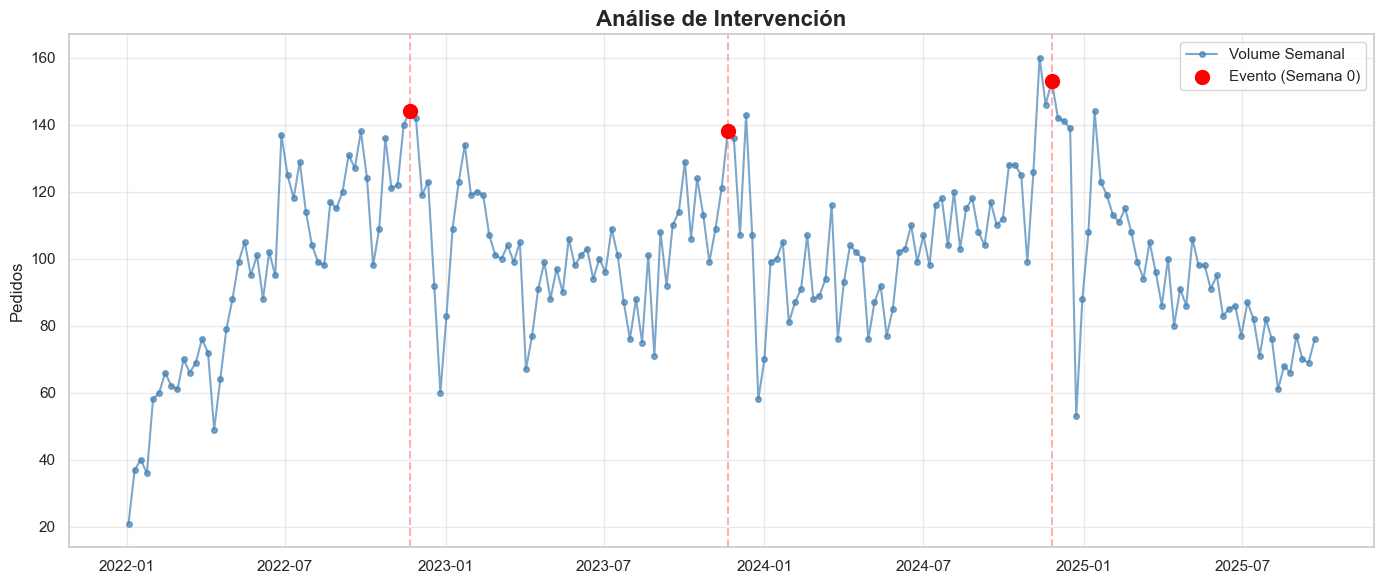

In [5]:
ft.plot_analisis_intervencion(df_input=df_global,
                              fechas_clave=fechas_bf)

Modélase o impacto do Black Friday nas dúas semanas previas e nas dúas posteriores.

In [6]:
modelo = 'Global'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_global)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=2 
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q)X(P,D,Q)

#### Gráfico secuencial, fas e fap

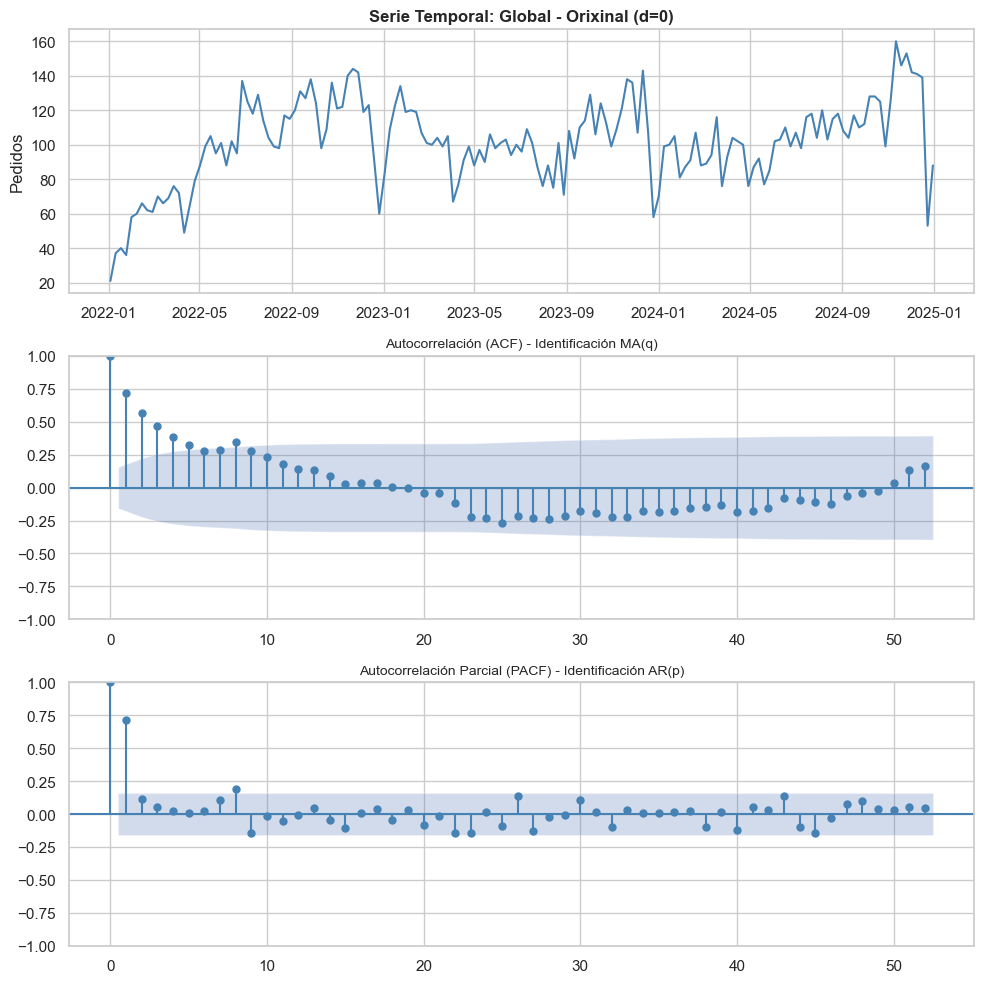

In [7]:
modelo = 'Global'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{'Global'} - Orixinal (d=0)"
)

Ante a presente tendencia, diferénciase a serie regularmente ($d = 1$):

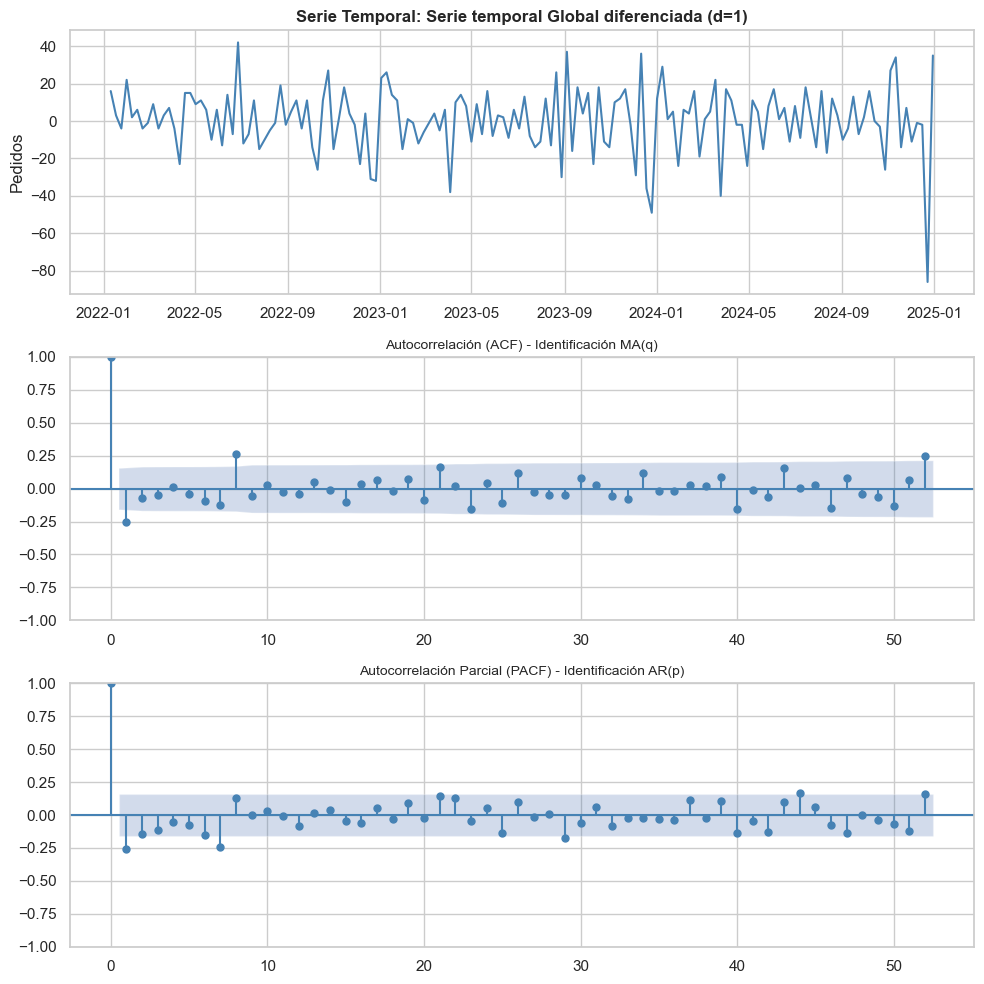

In [8]:
y_diff = datos_arima[modelo]['y_train'].diff().dropna()

ft.plot_identificacion_arima(
    y_diff,
    lags=52,
    titulo='Serie temporal Global diferenciada (d=1)'
)

Modelos suxeridos: ARIMA(1,1,0) ou  ARIMA(0,1,1).

#### Selección do modelo mediante AIC

In [9]:
modelo = 'Global'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1341.098, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1329.452, Time=0.35 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1318.754, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1339.195, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1316.746, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1319.119, Time=0.22 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1318.761, Time=0.24 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1317.332, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1326.009, Time=0.19 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1318.152, Time=0.33 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1315.764, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1317.262, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1327.575, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0]             :

In [10]:
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (1, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1327.5752567704865


In [11]:
manual_order = (0, 1, 1)

model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')
model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])
best_order = manual_order
print(f"Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

Modelo ARIMA (0, 1, 1) axustado correctamente.
AIC = 1317.2624743963434


ARIMA(0,1,1) seleccionado.

In [12]:
print(model_manual.summary())
best_order = manual_order

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -653.631
Date:                Tue, 13 Jan 2026   AIC                           1317.262
Time:                        23:19:30   BIC                           1332.512
Sample:                    01-03-2022   HQIC                          1323.456
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre        19.3197      6.894      2.802      0.005       5.808      32.832
bf_peak       32.4756     16.318      1.990      0.047       0.493      64.458
bf_post       21.4005      5.397      3.966      0.0

#### Detección de atípicos (aditivos e innovativos)

In [13]:
modelo = 'Global'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y= datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    
    max_iter=10,    
    burn_in=3      
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order


🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.72 > 3.59
   [Iter 2] Detectado: 2023-12-25 | t-stat: 3.75 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.15). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.716692     1  Negativo
1 2023-12-25 -3.752504     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20231225
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Detéctanse dous outliers: 25/12/2023 e 23/12/2024.

#### Estimación ou axuste do modelo

In [14]:
modelo = 'Global'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima['Global']['X_train_final'].shape[1]} variables exóxenas...")

# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],      
    order=datos_arima[modelo]['order'],         
    trend='n',               
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_axuste.fit(disp=False)

print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(0, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -630.563
Date:                Tue, 13 Jan 2026   AIC                           1275.126
Time:                        23:19:30   BIC                           1296.385
Sample:                    01-03-2022   HQIC                          1283.761
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              16.0029      5.913      2.706      0.007       4.414      27.592
bf_peak             27.2634     13.454     

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Todos os coeficientes do modelo son significativos. 

#### Diagnose ou análise dos residuos

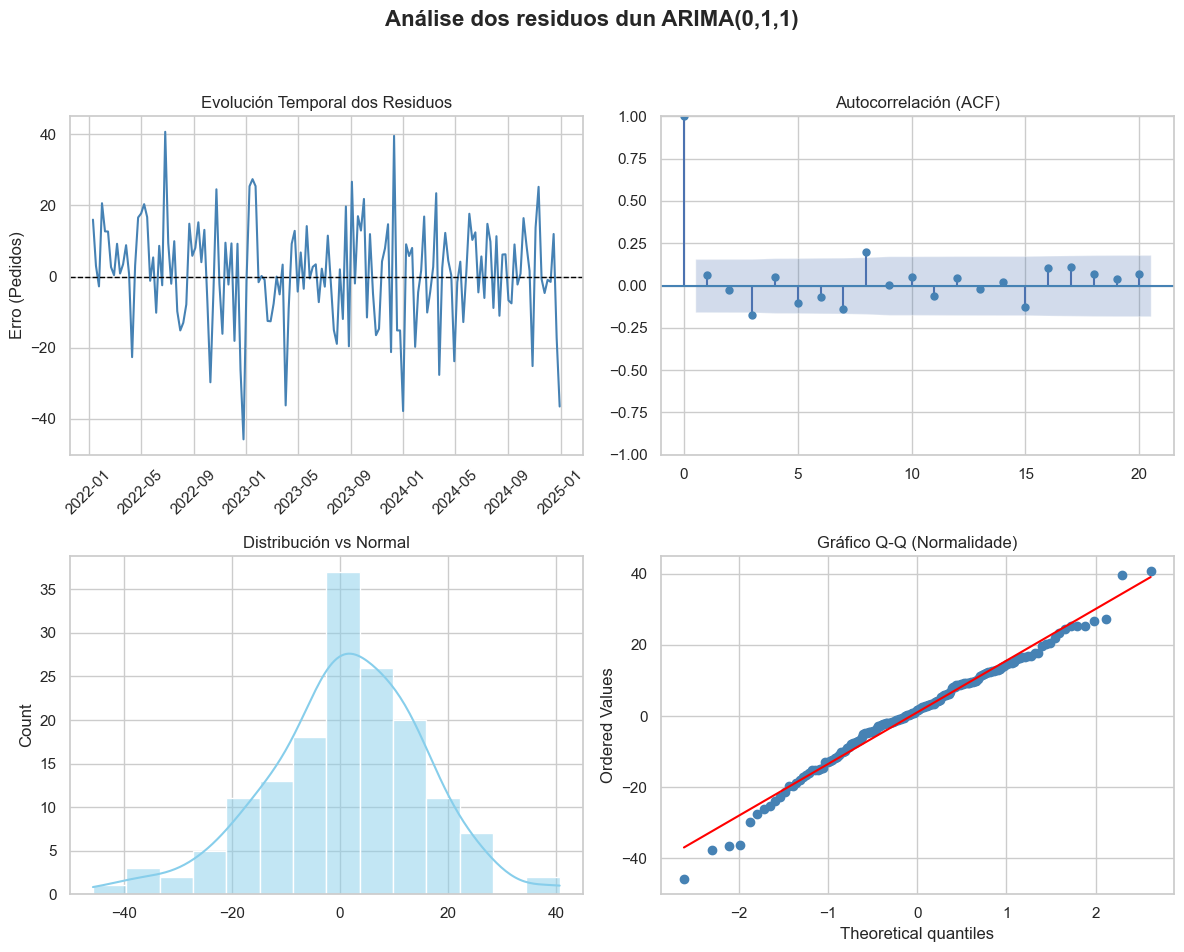


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(0,1,1) ---
1️⃣  Sesgo (Media=0):  p-value = 0.3675 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.1032 ✅ (Aceptamos H0: Residuos normais)
------------------------------------------------------------


In [15]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(0,1,1)')

In [16]:
print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -630.563
Date:                Tue, 13 Jan 2026   AIC                           1275.126
Time:                        23:19:31   BIC                           1296.385
Sample:                    01-03-2022   HQIC                          1283.761
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              16.0029      5.913      2.706      0.007       4.414      27.592
bf_peak             27.2634     13.454      2.026      0.043       0.893      53.633
bf_post             14.7547 

Normalidade no límite de rexeitamento (p-valor = $0.05$). O resto de hipóteses satisfanse.

#### Predicións

---VALIDACIÓN ROLLING WINDOW: Global ---
   Variables en modelo: 5
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 10/38: Pred=106.16


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 20/38: Pred=96.98


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 30/38: Pred=77.75


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


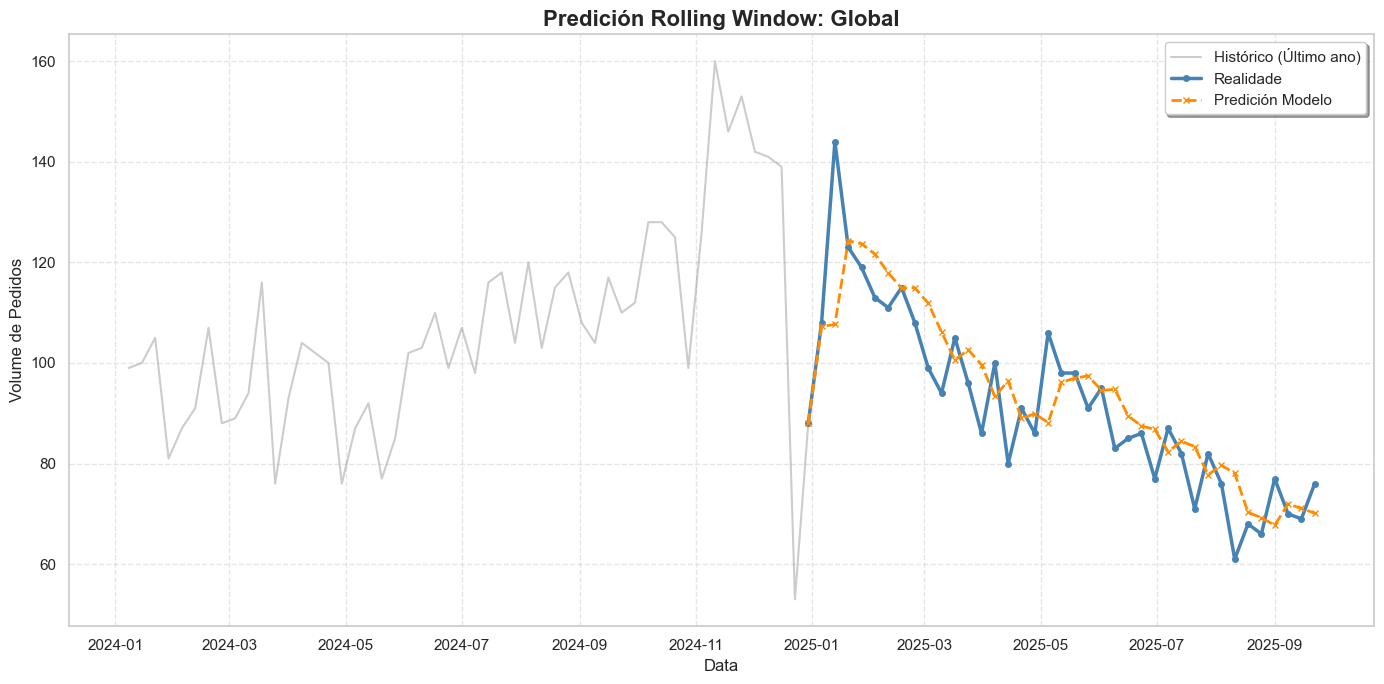

In [17]:
modelo = 'Global'
print(f"---VALIDACIÓN ROLLING WINDOW: {modelo} ---")
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)
print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")
print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")
preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], 
    order=datos_arima[modelo]['order'],
    trend='n',             
    verbose=True           
)
datos_arima[modelo]['predicions'] = preds_rolling
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [18]:
modelo = 'Global'
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- 📊 AVALIACIÓN: Global (Rolling) ---
MAE:  7.07
RMSE: 9.84
MAPE: 7.81%
MASE: 0.54 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Información precisa para Prophet:

In [19]:
modelo = 'Global'
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

export_para_prophet[modelo] = df_prophet

print(f"\n Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Global ---
   💾 Empaquetando datos de Global para Prophet...

 Datos exportados para Global.
   Dimensións: (195, 7)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_pre  bf_peak  bf_post  outlier_20241223  \
190 2025-08-25         66       0        0        0                 0   
191 2025-09-01         77       0        0        0                 0   
192 2025-09-08         70       0        0        0                 0   
193 2025-09-15         69       0        0        0                 0   
194 2025-09-22         76       0        0        0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Modelo por cluster

### Cluster 1

Clientes dos sectores de transporte, retail e electrónica.

In [20]:
df_cluster_1 = datos['Cluster 1'].set_index('semana')

#### Análise de intervención: Black Friday

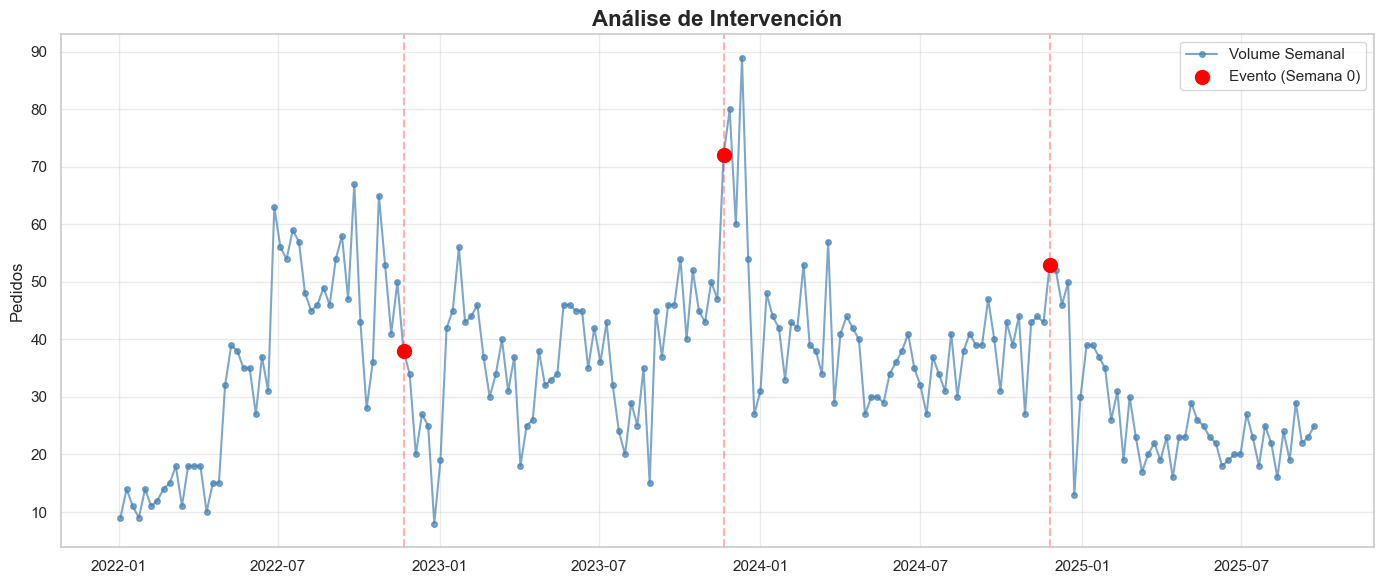

In [21]:
ft.plot_analisis_intervencion(df_input=df_cluster_1,
                              fechas_clave=fechas_bf)

Efecto do Black Friday icnluíndo a semana previa e a posterior.

In [22]:
modelo = 'Cluster 1'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_1)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

#### Gráfico secuencial, fas e fap

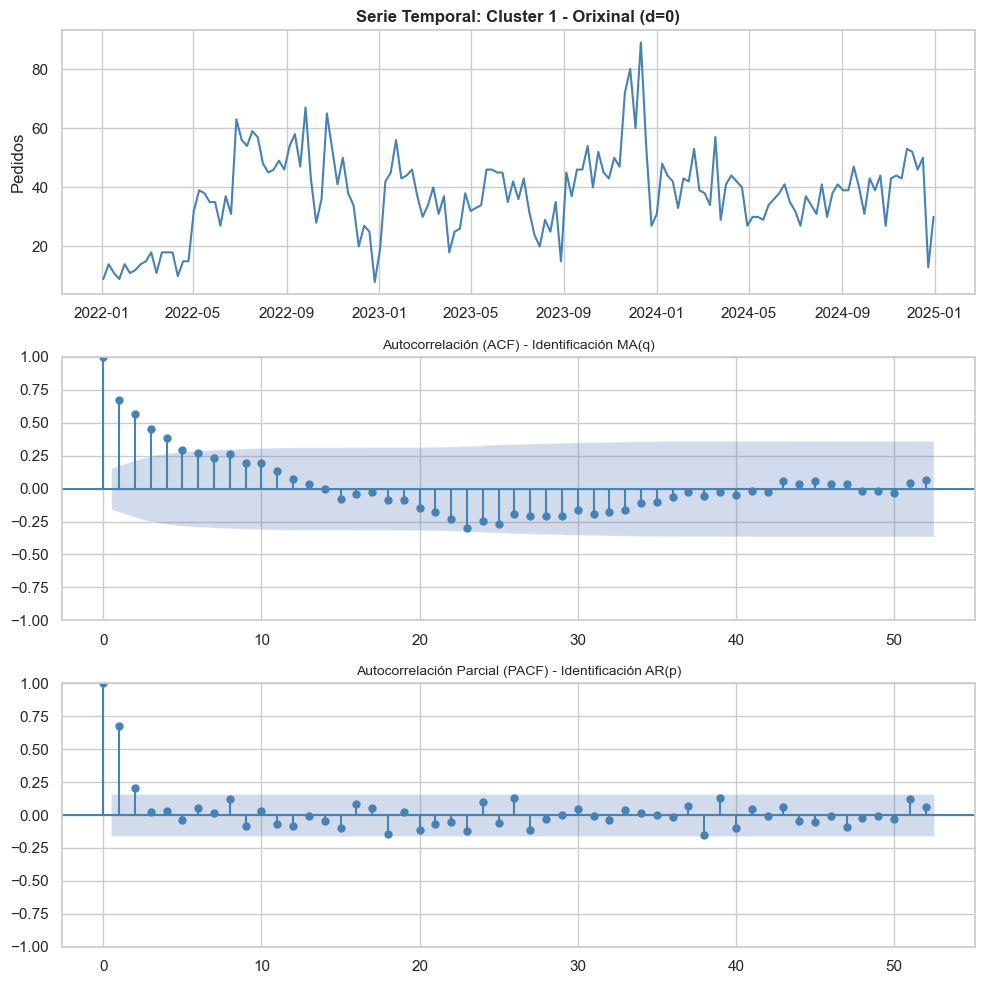

In [23]:
modelo = 'Cluster 1'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

Ante a tendencia positiva diferénciase regularmente ($d=1$).

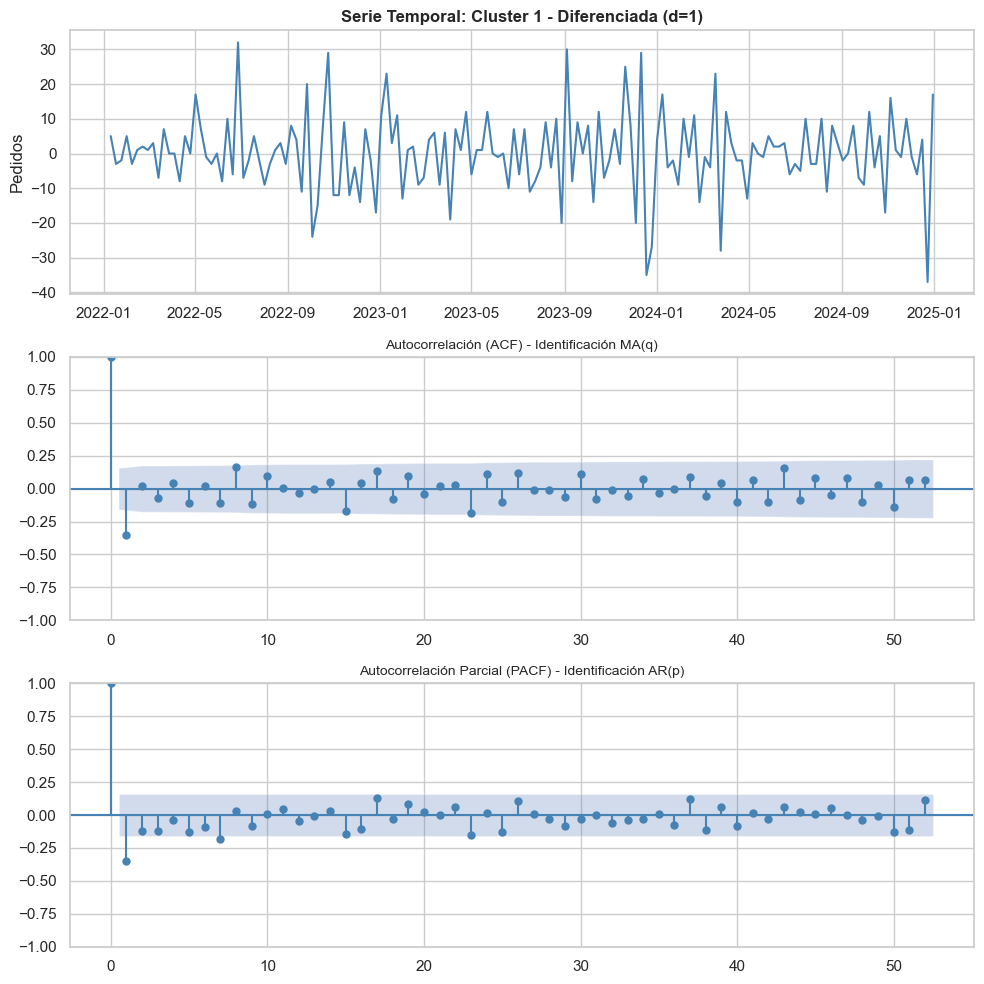

In [24]:
modelo = 'Cluster 1'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Diferenciada (d=1)"
)

Modelos suxeridos: ARIMA(1,1,0) ou ARIMA(0,1,1).

#### Selección do modelo mediante AICc

Unha vez suxerido un modelo que poida explicar a nosa serie, imos seleccionar aquel que minimiza o AIC

In [25]:
modelo = 'Cluster 1'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1595.507, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1207.640, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1457.126, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1191.279, Time=0.09 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=1190.914, Time=0.14 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=1188.695, Time=0.20 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=1190.399, Time=0.24 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.43 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=1183.129, Time=0.52 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=1181.260, Time=0.18 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1179.609, Time=0.49 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1184.724, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1182.615, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=

In [26]:
modelo = 'Cluster 1'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (0, 1, 1)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (0, 1, 1) axustado correctamente.


AIC = 1174.9608715325155


In [27]:
modelo = 'Cluster 1'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (1, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1181.4020172939927


Obrigamos a que a selección automática diferencie regularmente ($d=1$)

In [28]:
modelo = 'Cluster 1'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1201.215, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1183.376, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1176.876, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1199.238, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1175.289, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1176.259, Time=0.30 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1176.658, Time=0.12 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1182.632, Time=0.15 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1175.973, Time=0.20 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1173.562, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1174.961, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1181.402, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=117

Selecciónase o ARIMA(0,1,1)

In [29]:
manual_order = (0,1,1)
best_order = manual_order

#### Detección de atípicos (aditivos e innovativos)

Fagamos agora o contraste de detección de outliers do mesmo xeito que no caso anterior:

**Nota**: xa temos a función construída.

In [30]:
modelo = 'Cluster 1'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))

# Gardamos este novo X (que agora ten BF + Outliers) nun novo dicionario
# Este será o input para a seguinte fase (Refinado / Backward Elimination)
if 'datos_arima_final' not in locals():
    datos_arima_final = {}

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2023-12-25 | t-stat: 3.65 > 3.59
   [Iter 2] Non se atoparon máis atípicos significativos (Max t: 3.41). Fin.
       fecha    t_stat  iter      tipo
0 2023-12-25 -3.652071     1  Negativo
            bf_pre  bf_peak  bf_post  outlier_20231225
semana                                                
2022-01-03       0        0        0                 0
2022-01-10       0        0        0                 0
2022-01-17       0        0        0                 0
2022-01-24       0        0        0                 0
2022-01-31       0        0        0                 0


Atípico en 25/12/2023

#### Estimación ou axuste do modelo

Unha vez visto que non se detectan atípicos, axustemos o modelo e vexamos se todos os coeficientes son significativos ou non:

In [31]:
modelo = 'Cluster 1'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(0, 1, 1) con 4 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -571.941
Date:                Tue, 13 Jan 2026   AIC                           1155.882
Time:                        23:19:46   BIC                           1174.104
Sample:                    01-03-2022   HQIC                          1163.284
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               2.3057     10.734      0.215      0.830     -18.733      23.344
bf_peak             10.4020      5.650     

In [32]:
modelo = 'Cluster 1'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
✅ Variable 'bf_pre' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(0, 1, 1) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -572.040
Date:                Tue, 13 Jan 2026   AIC                           1154.079
Time:                        23:19:46   BIC                           1169.264
Sample:                    01-03-2022   HQIC                          1160.247
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak            

Todos os coeficientes son significativos.

#### Diagnose ou análise dos residuos

Imos comprobar as hipóteses do modelo e ver así se o modelo axustado é válido. 
A hipótese fundamental a contrastar é a que esixe que as innovacións $\{a_t\}$ sexan ruído blanco, isto é:
1. Media cero
2. Homocedasticidade
3. Incorreladas

Graficamente:

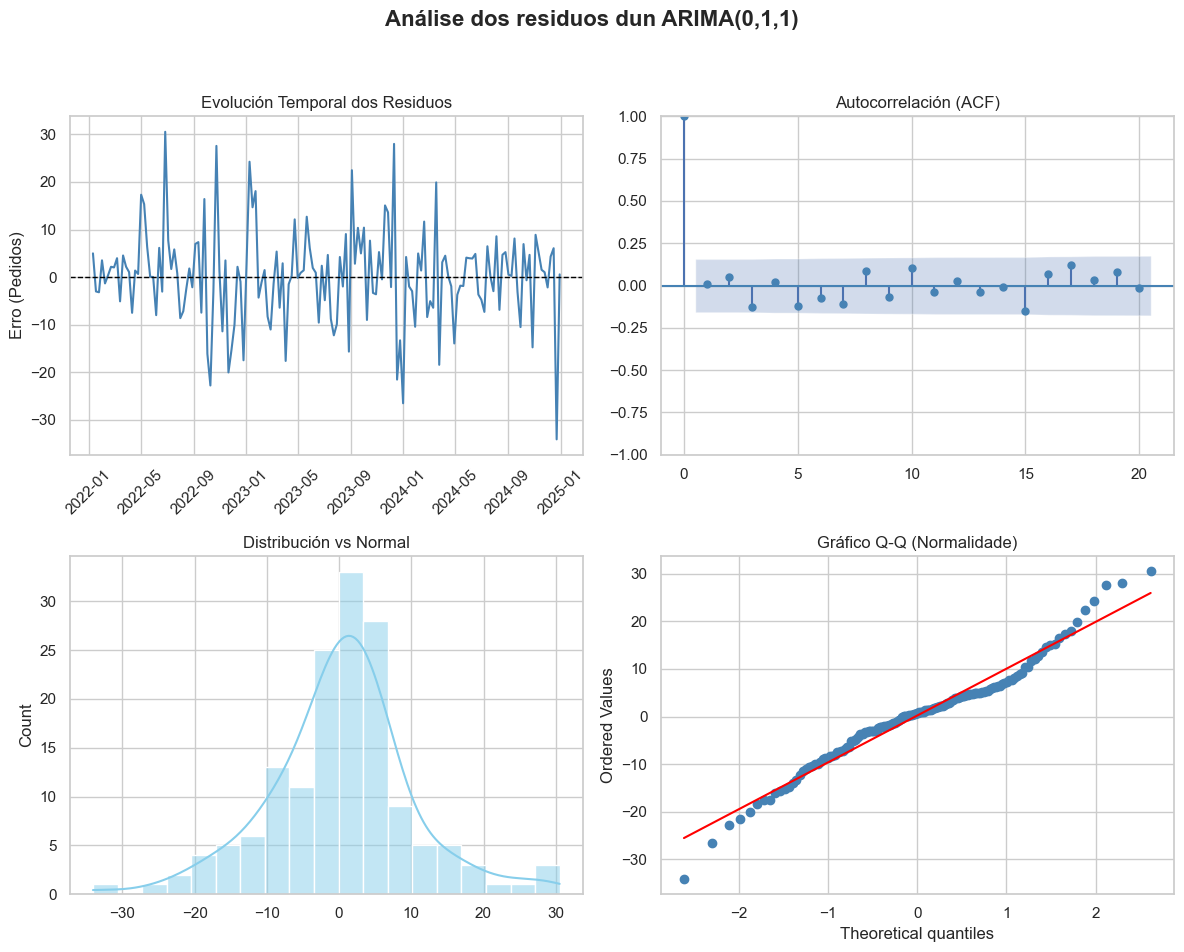


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(0,1,1) ---
1️⃣  Sesgo (Media=0):  p-value = 0.7717 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0015 ⚠️ (Rexeitamos H0: Non son perfectamente normais)
------------------------------------------------------------


In [33]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(0,1,1)')

Graficamente, no gráfico secuencial da serie non observamos problemas de heterocedasticidade. Nas fas mostrais tampouco vemos problemas de correlación. Ademáis, vendo o histograma e o QQ-plot, pode verse unha distribución con certa asimetría polo que é posible que falle a normalidade dos residuos.

Debemos facer os contrastes numéricos para asegurarnos do cumprimento das hipóteses do modelo.

In [34]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -572.040
Date:                Tue, 13 Jan 2026   AIC                           1154.079
Time:                        23:19:46   BIC                           1169.264
Sample:                    01-03-2022   HQIC                          1160.247
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak              9.7058      3.692      2.629      0.009       2.470      16.941
bf_post             11.3606      4.460      2.547      0.011       2.620      20.101
outlier_20231225   -24.0962      5.343     -4.510      0.000     -34.568     -13.625
ma.L1               -0.4818      0.069     -7.032      0.000      -0.616      -0.348
sigma2              98.5746      8.826     11.168      0.000      81.275     115.874
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                13.61
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.62   Skew:                            -0.02
Prob(H) (two-sided):                  0.09   Kurtosis:                         4.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Modelo válido con innovacións non gaussianas.

#### Predicións

--- 🔮 VALIDACIÓN ROLLING WINDOW: Cluster 1 ---
   Variables en modelo: 3
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=25.19
   > Semana 20/38: Pred=25.79
   > Semana 30/38: Pred=20.57


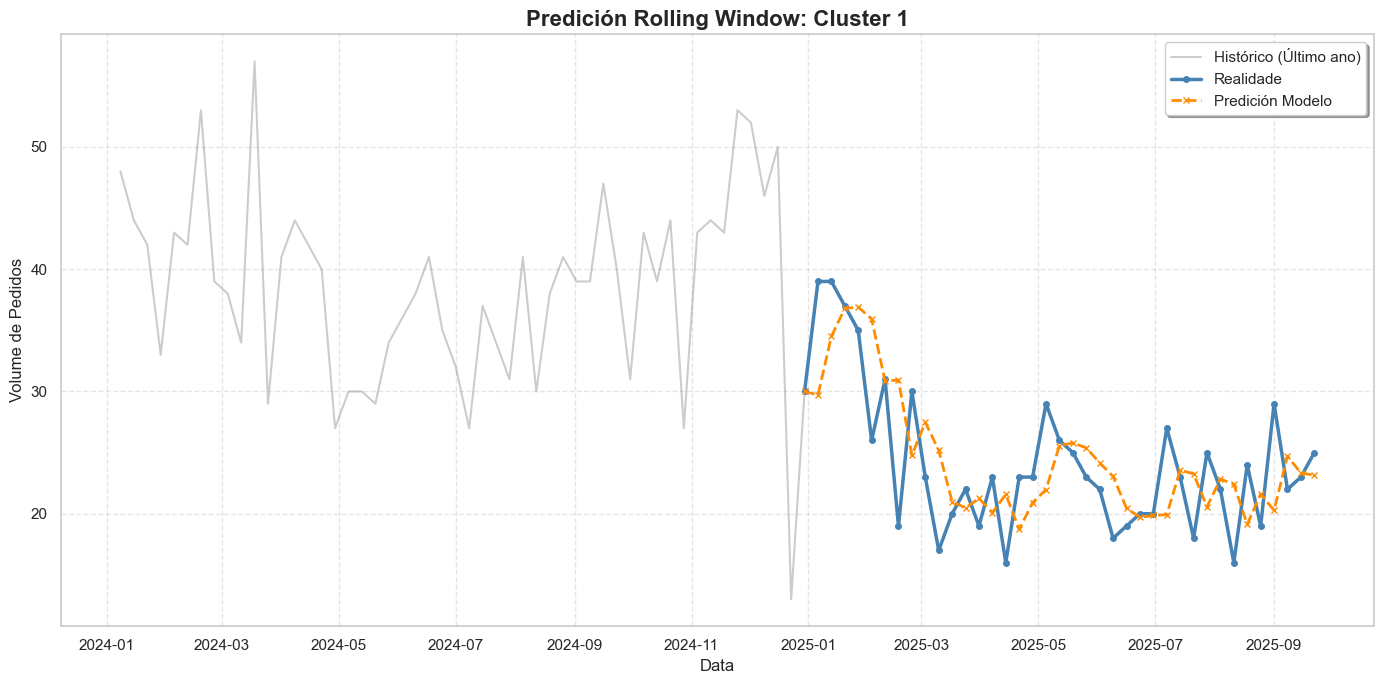

In [35]:
modelo = 'Cluster 1'
print(f"--- 🔮 VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW
# Usamos a función 'arimax' porque confirmamos que NON hai estacionalidade
preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], # Pasamos o Test coas columnas corrixidas
    order=datos_arima[modelo]['order'],
    trend='n',             # Sen tendencia (xa diferenciamos ou non é significativa)
    verbose=True           # Para ver o progreso semana a semana
)
# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling
# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [36]:
modelo = 'Cluster 1'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo (comparas contra o valor da semana anterior)
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- 📊 AVALIACIÓN: Cluster 1 (Rolling) ---
MAE:  3.70
RMSE: 4.82
MAPE: 16.28%
MASE: 0.45 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Resultados practicamente idénticos aos datos orixinais.

Gardamos a información de atípicos e análise de intervención para empregar no Prophet:

In [37]:
modelo = 'Cluster 1'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n✅ Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Cluster 1 ---
   💾 Empaquetando datos de Cluster 1 para Prophet...

✅ Datos exportados para Cluster 1.
   Dimensións: (195, 5)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_peak', 'bf_post', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_peak  bf_post  outlier_20231225
190 2025-08-25         19        0        0                 0
191 2025-09-01         29        0        0                 0
192 2025-09-08         22        0        0                 0
193 2025-09-15         23        0        0                 0
194 2025-09-22         25        0        0                 0


### Cluster 2

Pasamos agora a axustar un modelo ARIMA para o cluster formado polos clientes de paquetería e froita.

In [38]:
df_cluster_2 = datos['Cluster 2'].set_index('semana')

#### Análise de intervención: Black Friday

Novamente repetimos a análise do impacto do Black Friday, agora sobre os clientes do segundo cluster.

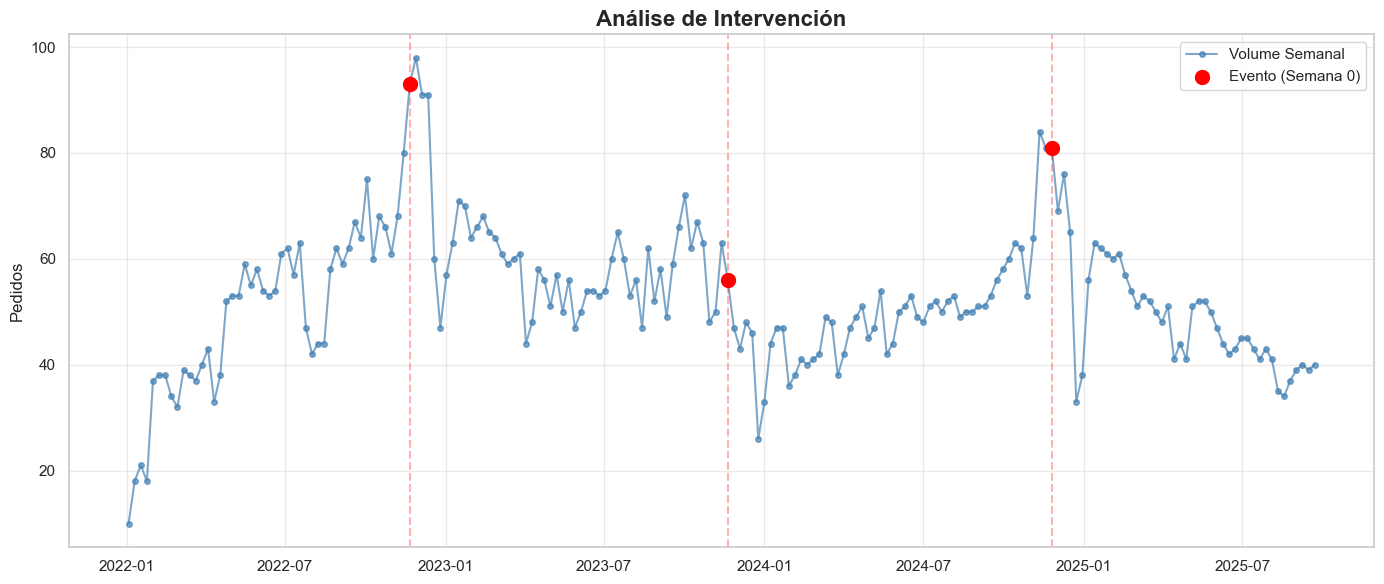

In [39]:
ft.plot_analisis_intervencion(df_input=df_cluster_2,
                              fechas_clave=fechas_bf)

Graficamente, vemos como o efecto previo do B-F se extende pricipalmente ás dúas semanas anteriores (sobre todo no 2022 e 2024). Ademáis, no 2022 observamos como o pico se exntende unha semana e despois cae, mentres uqe no 2023 e 2024 cae na seguinte semana (no 2023 en particular é maior o efecto na semana previa ca na propia semana do evento). 

Así, decidimos modelar o efecto do B-F con 3 variables dummys. Aprimeira plasmará o efecto das dúas semanas previas, a segunda a da propia semana e a última o efecto da semana posterior.

In [40]:
modelo = 'Cluster 2'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_2)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap

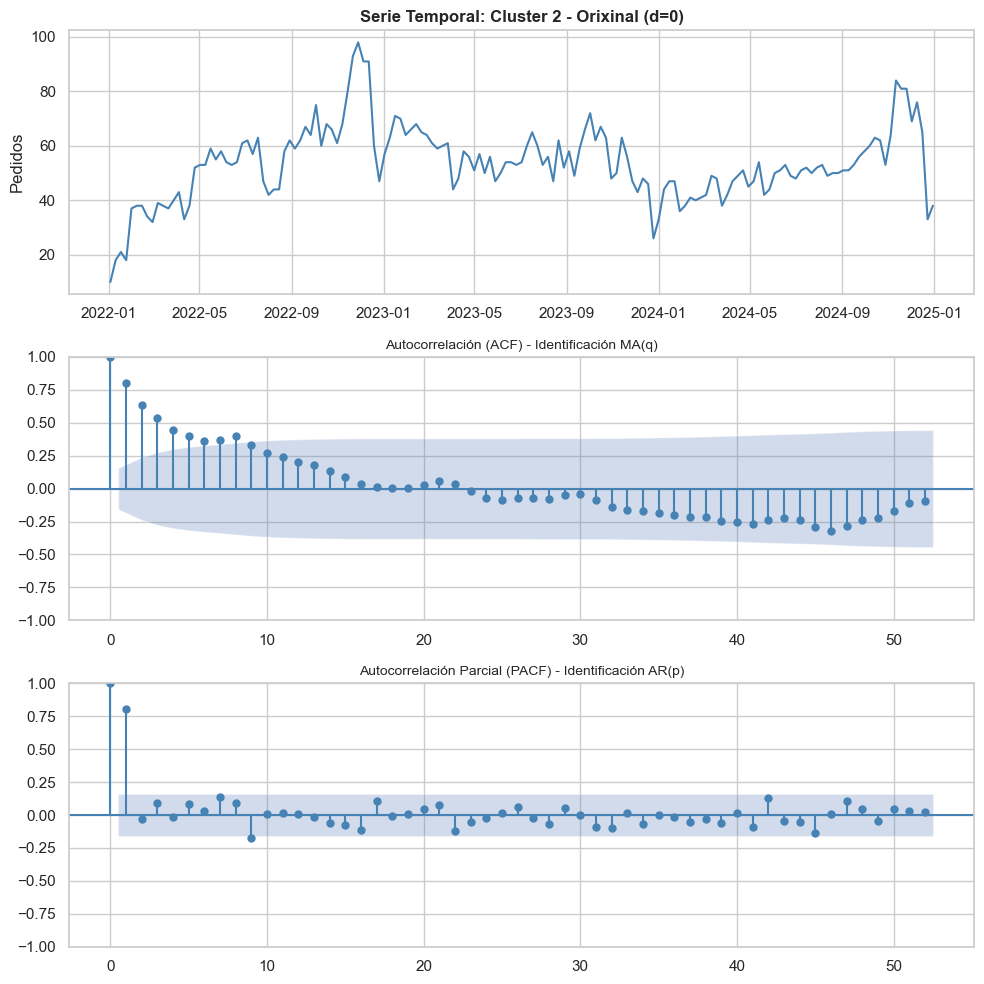

In [41]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

Observando o gráfico secuencial e a fas mostral, podemos intuir a presenza de tendencia. Polo tanto, podemos pensar en repetir os gráficos unha vez diferenciada a serie.

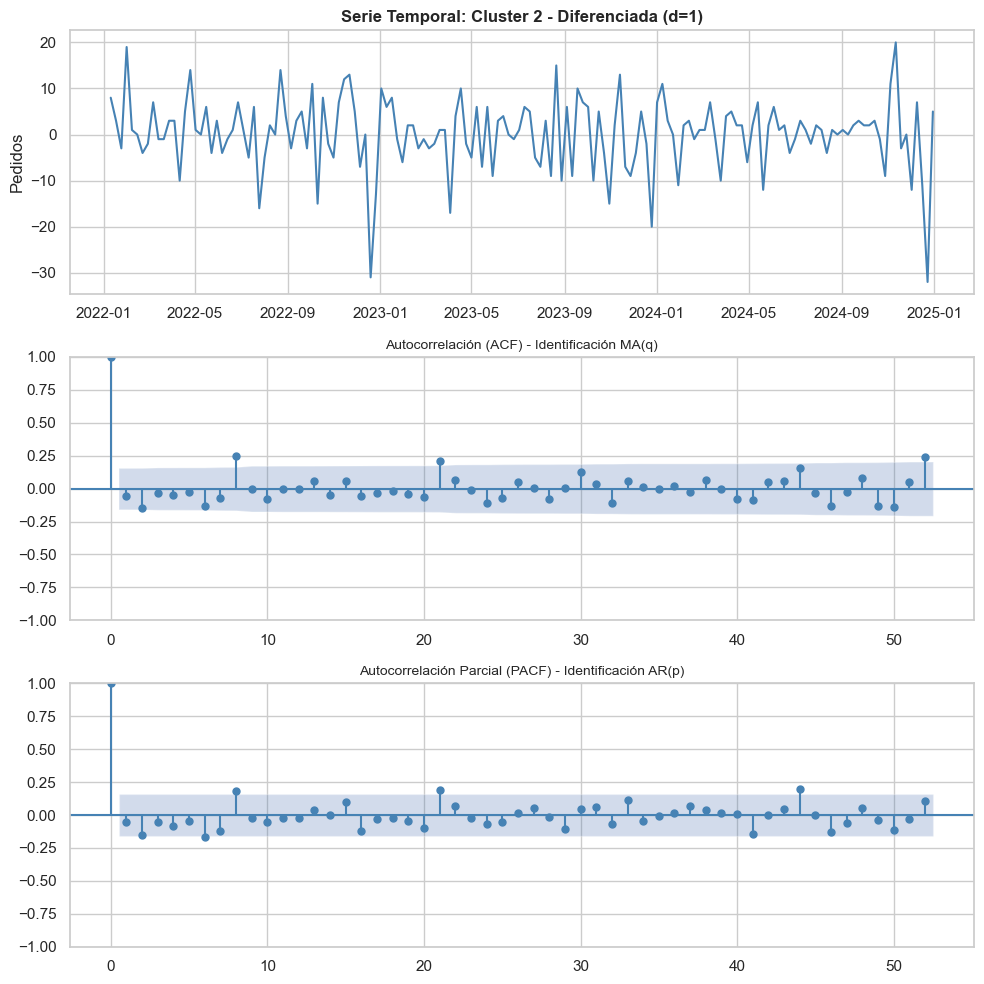

In [42]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Diferenciada (d=1)"
)

Unha vez diferenciada a serie, non se observan problemas de estacionalidade nin heterocedasticidade. Ademáis, observando os gráficos das fas e fap mostrais podemos suxerir un ARMA(0,0) para a serie diferenciada. Daquela, para a serie orixinal poderiamos suxerir un ARIMA(0,1,0)

#### Selección do modelo mediante AICc

In [43]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1691.548, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1094.293, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1095.594, Time=0.60 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1095.255, Time=0.37 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1085.674, Time=0.24 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1249.817, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1087.708, Time=0.49 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1087.263, Time=0.38 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1155.288, Time=0.28 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.34 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 3.393 seconds
                               SARIMAX Re

In [44]:
modelo = 'Cluster 2'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (0, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (0, 1, 0) axustado correctamente.
AIC = 1083.060947087964


Vemos daquela como o modelo suxerido pola interpretación gráica sería mellor ao modelo axustado automaticamente. (Que a función auto_arima non probe modelos con d=1 débese a que non rexeita a estacionariedade da serie de partida. Sinalemos que graficamente tampouco é que se observase unha gran tendencia.). Obligamos entón ao criterio automático a avaliar os modelos con d=1.

In [45]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d=1
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1084.974, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1086.185, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1085.784, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1083.061, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.639 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -537.530
Date:                Tue, 13 Jan 2026   AIC                           1083.061
Time:                        23:19:55   BIC                           1095.260
Sample:                    01-03-2022   HQIC                          1088.016
                      

In [46]:
best_order = modelo_global.order

#### Detección de atípicos (aditivos e innovativos)

Pasamos agora á detección de outliers mediante a función que definimos no primeiro modelo axustado:

In [47]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.19 > 3.59
   [Iter 2] Detectado: 2022-12-19 | t-stat: 4.23 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.03). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.193103     1  Negativo
1 2022-12-19 -4.227691     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20221219
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


Atípicos en 19/12/2022 e 23/12/2024.

#### Estimación ou axuste do modelo

Axustamos o modelo resultante e vemos se os seus parámetros son significativos ou non.

In [48]:
modelo = 'Cluster 2'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(0, 1, 0) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -526.303
Date:                Tue, 13 Jan 2026   AIC                           1064.607
Time:                        23:19:55   BIC                           1082.867
Sample:                    01-03-2022   HQIC                          1072.024
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               8.4167      3.445      2.443      0.015       1.664      15.169
bf_peak              9.1667      4.067     

In [49]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...
✅ Variable 'bf_post' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(0, 1, 0) coas 4 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -526.559
Date:                Tue, 13 Jan 2026   AIC                           1063.118
Time:                        23:19:55   BIC                           1078.335
Sample:                    01-03-2022   HQIC                          1069.299
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre           

Todos os coeficientes significativos.

#### Diagnose ou análise dos residuos

Graficamente:

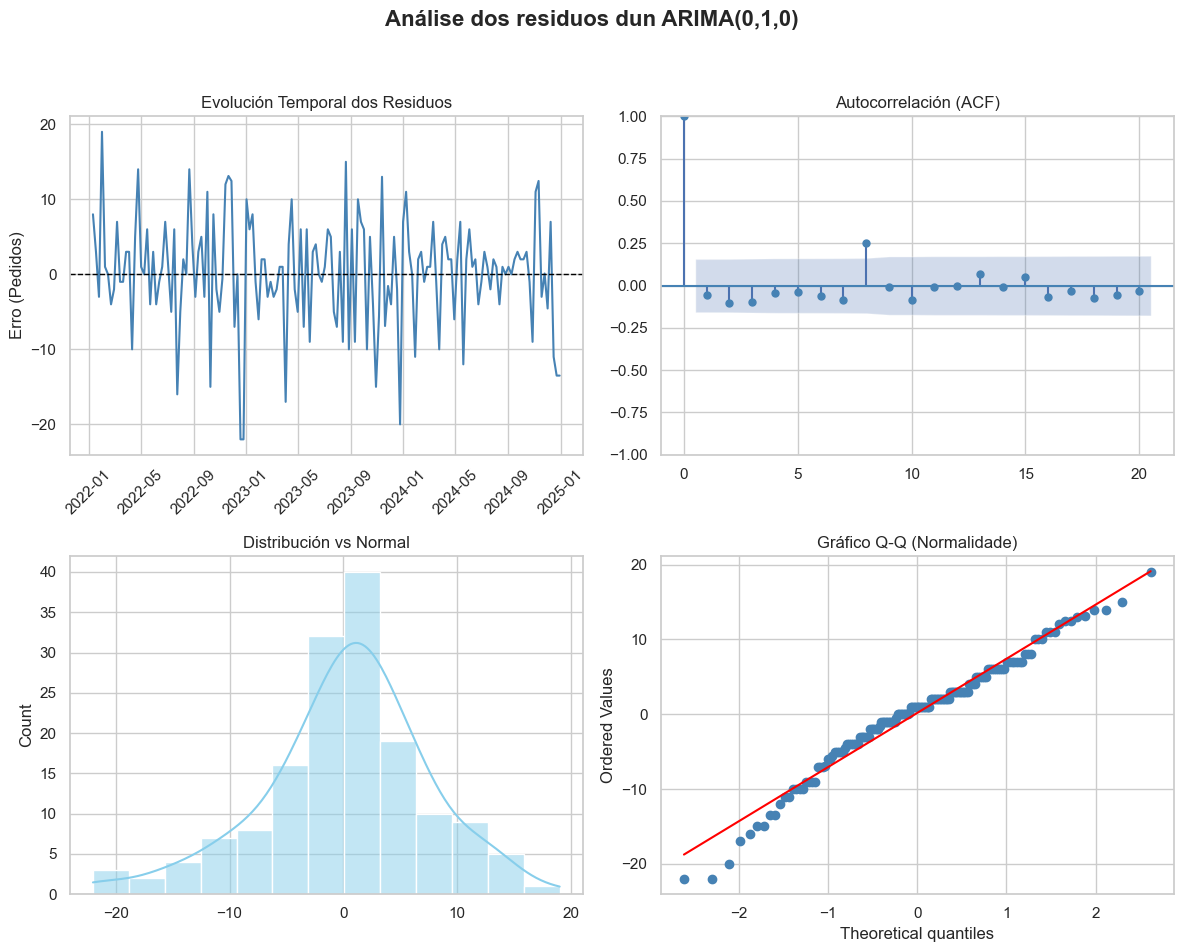


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(0,1,0) ---
1️⃣  Sesgo (Media=0):  p-value = 0.7578 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0057 ⚠️ (Rexeitamos H0: Non son perfectamente normais)
------------------------------------------------------------


In [50]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(0,1,0)')

Graficamente non asemella que teñamos problemas nin de heterocedasticidade, nin correlación. Ademáis, parece tamén que os residuos teñen media 0. Porén a normalidade dos residuos seguramente non se vaia a cumprir. Fagamos os contrastes pertinentes:

In [51]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -526.559
Date:                Tue, 13 Jan 2026   AIC                           1063.118
Time:                        23:19:55   BIC                           1078.335
Sample:                    01-03-2022   HQIC                          1069.299
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               7.5556      3.100      2.437      0.015       1.480      13.632
bf_peak              7.4444      3.131      2.378      0.017       1.308      13.581
outlier_20241223   -18.5000      2.738     -6.757      0.000     -23.866     -13.134
outlier_20221219    -9.0000      1.680     -5.357      0.000     -12.293      -5.707
sigma2              52.2709      5.078     10.294      0.000      42.318      62.224
===================================================================================
Ljung-Box (L1) (Q):                   0.57   Jarque-Bera (JB):                 9.82
Prob(Q):                              0.45   Prob(JB):                         0.01
Heteroskedasticity (H):               0.49   Skew:                            -0.48
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Cuidado** non se cumpre a hipótese da homocedasticidade. Temos un p-valor no test de Homocedasticidade de 0.01 < 0.05, co cal debemos reaxustar o modelo.

#### Corrección da heterocedasticidade

Aplicaremos unha transformación logarítmica aos nosos datos e repetiremos o procedemento.

In [52]:
modelo = 'Cluster 2'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

**Selección das ordes (p,d,q)**

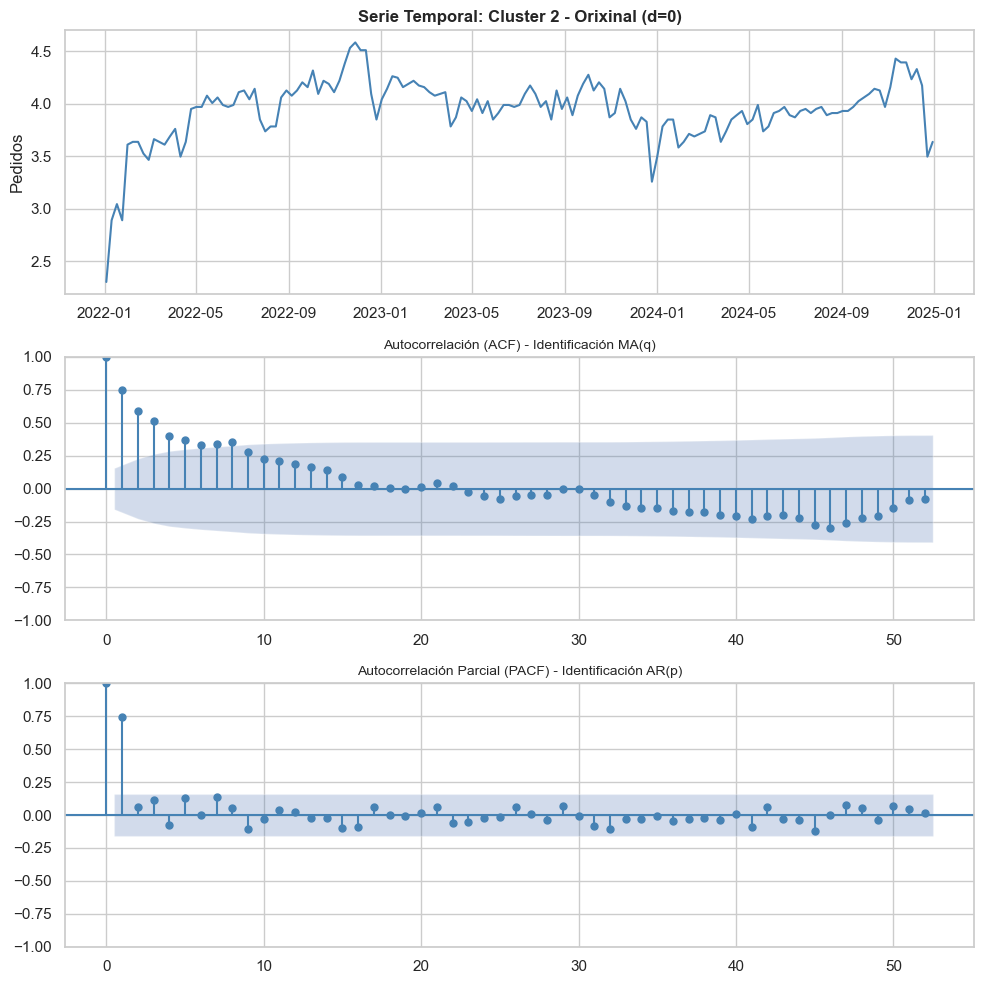

In [53]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

Seguimos vendo problemas de tendencia. Diferenciemos a serie transformada.

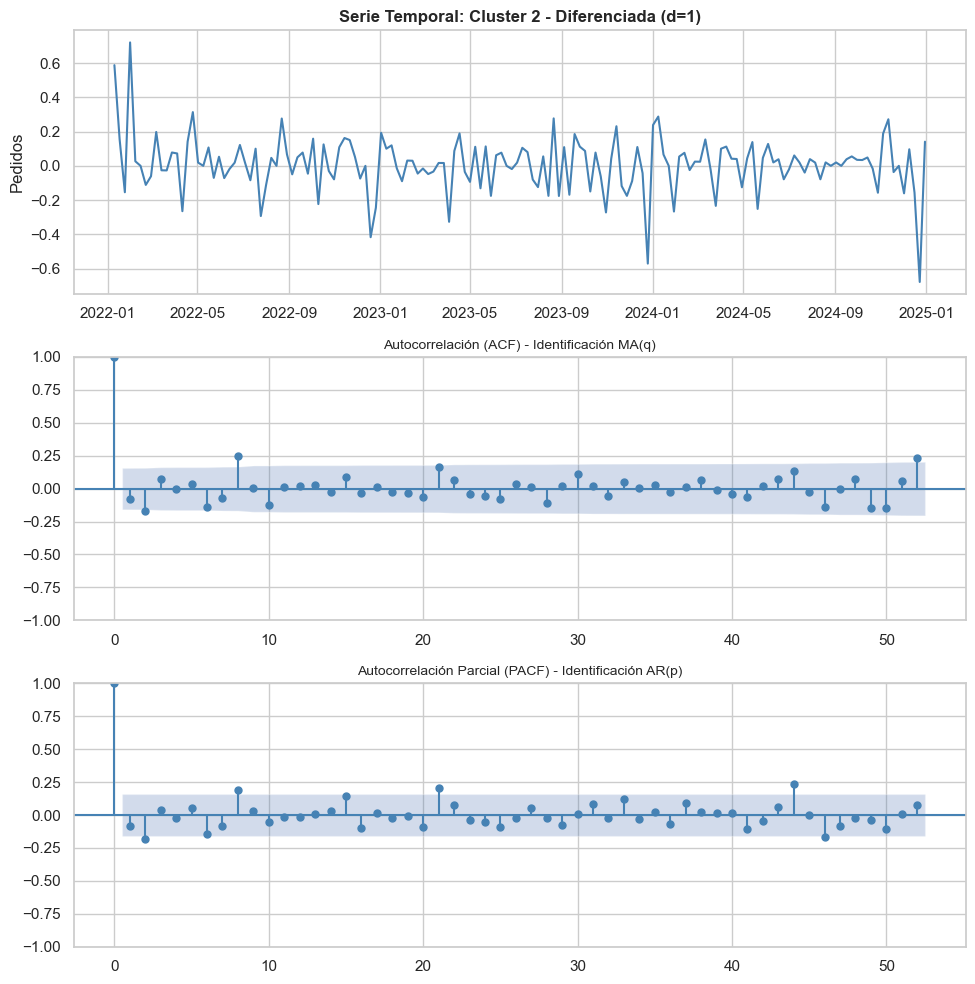

In [54]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Diferenciada (d=1)"
)

Para a serie do log diferenciada podemos suxerir un ARMA(0,0). Co cal a serie tranformada pode vir explicada por un ARIMA(0,1,0).

**Selección automática**

In [55]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=870.676, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.33 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-112.321, Time=0.33 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-109.416, Time=0.40 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-116.550, Time=0.74 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.38 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-111.362, Time=0.43 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-114.958, Time=0.68 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.53 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-113.253, Time=0.65 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-110.174, Time=0.63 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 5.299 seconds
                               SARIMAX Results 

O mellor modelo segundo o AIC sería un ARIMA(1,0,2). Novamente sucede que a función auto_arima non avalía modelos con d=1. Probemos manuealmente o ARIMA(0,1,0) e comparemos o AIC co suposto óptimo.

In [56]:
modelo = 'Cluster 2'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (0, 1, 2)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (0, 1, 2) axustado correctamente.
AIC = -123.72606435644605


In [57]:
modelo = 'Cluster 2'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (2, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (2, 1, 0) axustado correctamente.
AIC = -123.91931479139691


In [58]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-117.690, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-117.066, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-117.917, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-119.248, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-119.176, Time=0.27 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.729 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                  63.624
Date:                Tue, 13 Jan 2026   AIC                           -119.248
Time:                        23:20:02   BIC                           -107.049
Sample:                    01-03-2022   HQIC                          -114.294
                 

Non proba máis aló do ARIMA(1,1,1). Obrígase a partir de $p=q=2$:

In [59]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1,
    start_p = 2
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-122.695, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-117.690, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-117.066, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-117.917, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-119.248, Time=0.04 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-120.697, Time=0.25 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-120.697, Time=0.70 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-119.176, Time=0.14 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-118.699, Time=0.22 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-123.919, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-118.580, Time=0.05 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-121.920, Time=0.15 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-121.921, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AI

In [60]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1,
    start_q = 2
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-122.670, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-117.690, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-117.066, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-117.917, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-119.248, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-120.941, Time=0.25 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-120.947, Time=0.32 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-119.176, Time=0.15 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-119.343, Time=0.27 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-123.726, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-119.377, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-122.079, Time=0.11 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=-122.103, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AI

Daquela o mellor modelo sería un ARIMA(2,1,0) con AIC = -119.33. Como o modelo suxerido graficamente (ARIMA(0,1,0)) empeora en máis de dúas unidades o AIC óptimo, quedamos co modelo proposto polo criterio automático.

In [61]:
best_order = (2,1,0)

**Detección de atípicos**

In [62]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2022-01-31 | t-stat: 4.89 > 3.59
   [Iter 2] Detectado: 2024-12-23 | t-stat: 4.34 > 3.59
   [Iter 3] Detectado: 2023-12-25 | t-stat: 3.97 > 3.59
   [Iter 4] Non se atoparon máis atípicos significativos (Max t: 3.16). Fin.
       fecha    t_stat  iter      tipo
0 2022-01-31  4.891930     1  Positivo
1 2024-12-23 -4.339101     2  Negativo
2 2023-12-25 -3.967222     3  Negativo
            bf_pre  bf_peak  bf_post  outlier_20220131  outlier_20241223  \
semana                                                                     
2022-01-03       0        0        0                 0                 0   
2022-01-10       0        0        0                 0                 0   
2022-01-17       0        0        0                 0                 0   
2022-01-24       0        0        0                 0                 0   
2022-01-31       0        0        0                 1                 0   

            outl

Tres outliers: 31/01/2022, 23/12/2024 e 25/12/2023.

**Estimación ou axuste do modelo**

In [63]:
modelo = 'Cluster 2'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.478
Date:                Tue, 13 Jan 2026   AIC                           -170.956
Time:                        23:20:07   BIC                           -143.623
Sample:                    01-03-2022   HQIC                          -159.853
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1222      0.086      1.417      0.156      -0.047       0.291
bf_peak              0.1541      0.088     

Vemos como o coeficiente $\varphi_1$ non é significativo. Debemos fixalo a 0 reaxustar o modelo:

In [64]:
modelo = 'Cluster 2'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final = model_axuste.fit_constrained(constraints)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.220
Date:                Tue, 13 Jan 2026   AIC                           -172.441
Time:                        23:20:07   BIC                           -148.145
Sample:                    01-03-2022   HQIC                          -162.572
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1215      0.095      1.273      0.203      -0.066       0.309
bf_peak              0.1482      0.091     

In [65]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final = model_refinado.fit_constrained(constraints)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...
✅ Variable 'bf_post' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 5 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  93.634
Date:                Tue, 13 Jan 2026   AIC                           -173.269
Time:                        23:20:07   BIC                           -152.010
Sample:                    01-03-2022   HQIC                          -164.634
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre           

In [66]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
✅ Variable 'bf_pre' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 4 variables restantes...


                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  92.334
Date:                Tue, 13 Jan 2026   AIC                           -172.667
Time:                        23:20:07   BIC                           -154.446
Sample:                    01-03-2022   HQIC                          -165.266
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak              0.0541      0.062      0.874      0.382      -0.067       0.175
outlier_20220131     0.3880      0.036     10.659      0.000       0.317       0.459
outlier_20241223    -0.3839 

In [67]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
✅ Variable 'bf_peak' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.818
Date:                Tue, 13 Jan 2026   AIC                           -173.636
Time:                        23:20:07   BIC                           -158.451
Sample:                    01-03-2022   HQIC                          -167.468
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131 

Todos os termos significativos. 

**Diagnose ou validación do modelo**

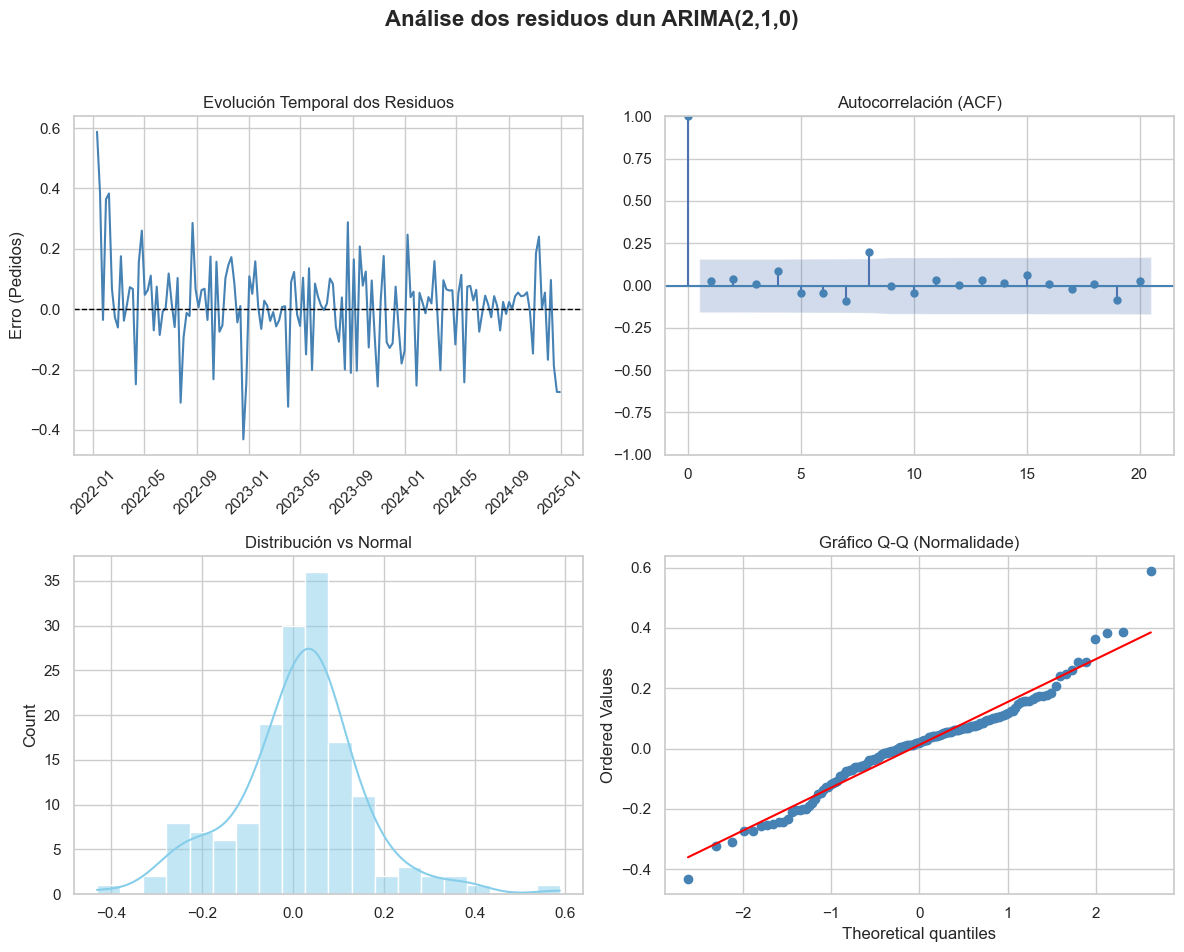


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(2,1,0) ---
1️⃣  Sesgo (Media=0):  p-value = 0.2808 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0005 ⚠️ (Rexeitamos H0: Non son perfectamente normais)
------------------------------------------------------------


In [68]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(2,1,0)')

O problema co primeiro residuo e pola propia construción do modelo (diferenciado) que non detecta dito dato como atípico polo algoritmo interno (non hai que preocuparse).

In [69]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.818
Date:                Tue, 13 Jan 2026   AIC                           -173.636
Time:                        23:20:08   BIC                           -158.451
Sample:                    01-03-2022   HQIC                          -167.468
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131     0.3876      0.037     10.604      0.000       0.316       0.459
outlier_20241223    -0.3843      0.047     -8.134      0.000      -0.477      -0.292
outlier_20231225    -0.3682      0.076     -4.817      0.000      -0.518      -0.218
ar.L1 (fixed)             0        nan        nan        nan         nan         nan
ar.L2               -0.2015      0.092     -2.191      0.028      -0.382      -0.021
sigma2               0.0178      0.002     10.199      0.000       0.014       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.25   Jarque-Bera (JB):                 6.92
Prob(Q):                              0.62   Prob(JB):                         0.03
Heteroskedasticity (H):               0.53   Skew:                            -0.34
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Aínda que p-valor $= 0.003$, graficamente non se ben problemas de heterocedasticidade.

#### Predicións

Moi impostante sinalar que, como axustamos o modelo á serie transformada (log), debemos facer as predicións con estos datos e, para poder interpretar e avaliar as métricas, transformar as predicións mediante a función inversa (exp):

--- 🔮 VALIDACIÓN ROLLING WINDOW: Cluster 2 ---
   Variables en modelo: 3
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (2, 1, 0)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...


   > Semana 10/38: Pred=3.95
   > Semana 20/38: Pred=3.90
   > Semana 30/38: Pred=3.73


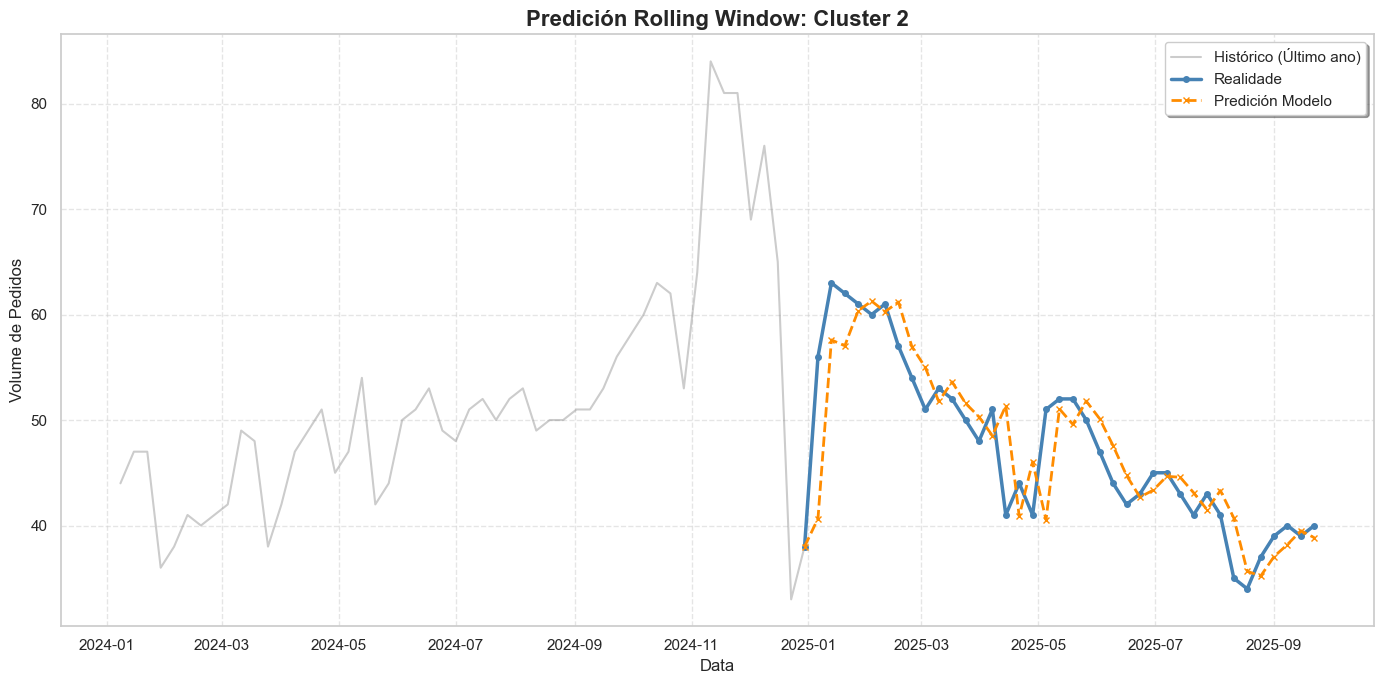

In [70]:
modelo = 'Cluster 2'
print(f"--- 🔮 VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW
# Usamos a función 'arimax' porque confirmamos que NON hai estacionalidade
preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], # Pasamos o Test coas columnas corrixidas
    order=datos_arima[modelo]['order'],
    trend='n',             # Sen tendencia (xa diferenciamos ou non é significativa)
    verbose=True           # Para ver o progreso semana a semana
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [71]:
modelo = 'Cluster 2'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo (comparas contra o valor da semana anterior)
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- 📊 AVALIACIÓN: Cluster 2 (Rolling) ---
MAE:  3.07
RMSE: 4.32
MAPE: 6.49%
MASE: 0.55 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Gardamos a información da análise de intervención e atípicos para empregar nos modelos Prophet:

In [72]:
modelo = 'Cluster 2'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n✅ Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Cluster 2 ---
   💾 Empaquetando datos de Cluster 2 para Prophet...

✅ Datos exportados para Cluster 2.
   Dimensións: (195, 5)
   Columnas incluídas: ['semana', 'n_pedidos', 'outlier_20220131', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  outlier_20220131  outlier_20241223  \
190 2025-08-25       37.0                 0                 0   
191 2025-09-01       39.0                 0                 0   
192 2025-09-08       40.0                 0                 0   
193 2025-09-15       39.0                 0                 0   
194 2025-09-22       40.0                 0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Cluster 3

Recordemos que o terceiro cluster estaba formado polos clientes de alimentación e industria.

In [73]:
df_cluster_3 = datos['Cluster 3'].set_index('semana')

#### Análise de intervención: efecto do Black Friday

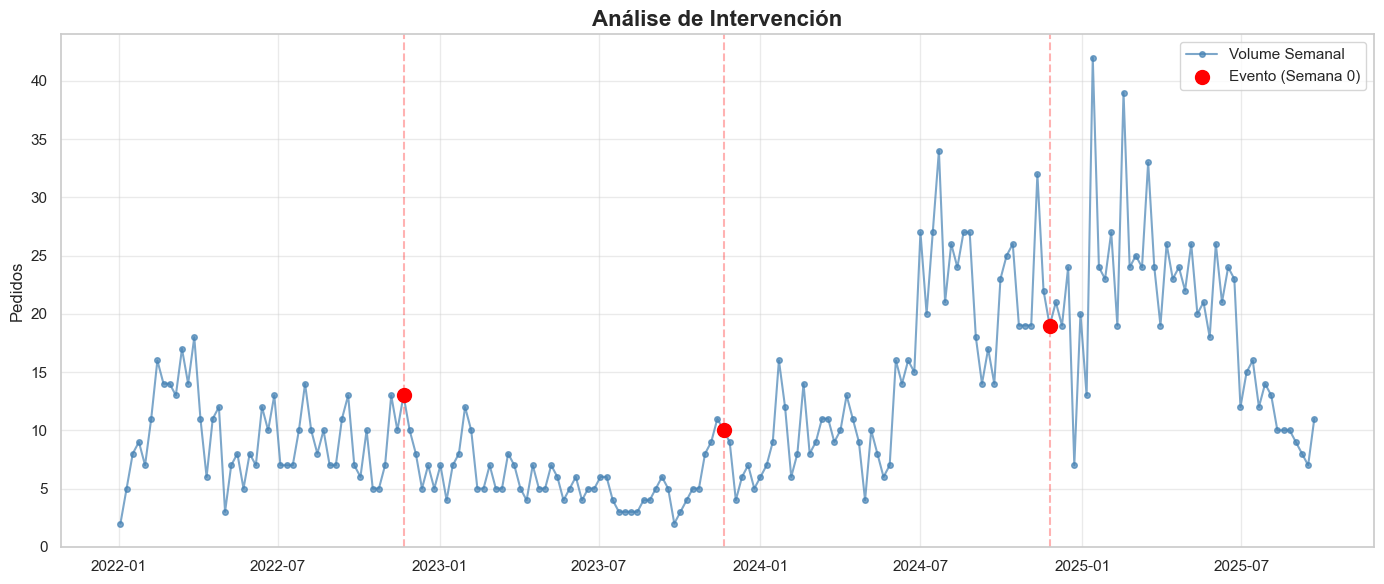

In [74]:
ft.plot_analisis_intervencion(df_input=df_cluster_3,
                              fechas_clave=fechas_bf)

Para os clientes deste cluster non apreciamos visualmente un gran impacto do Black Friday nin previo nin posterior. Porén, podemos modelar dita intervención e ver posterioremente se ten efecto significativo ou non á hora de axustar o modelo. 

In [75]:
modelo = 'Cluster 3'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_3)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap mostrais

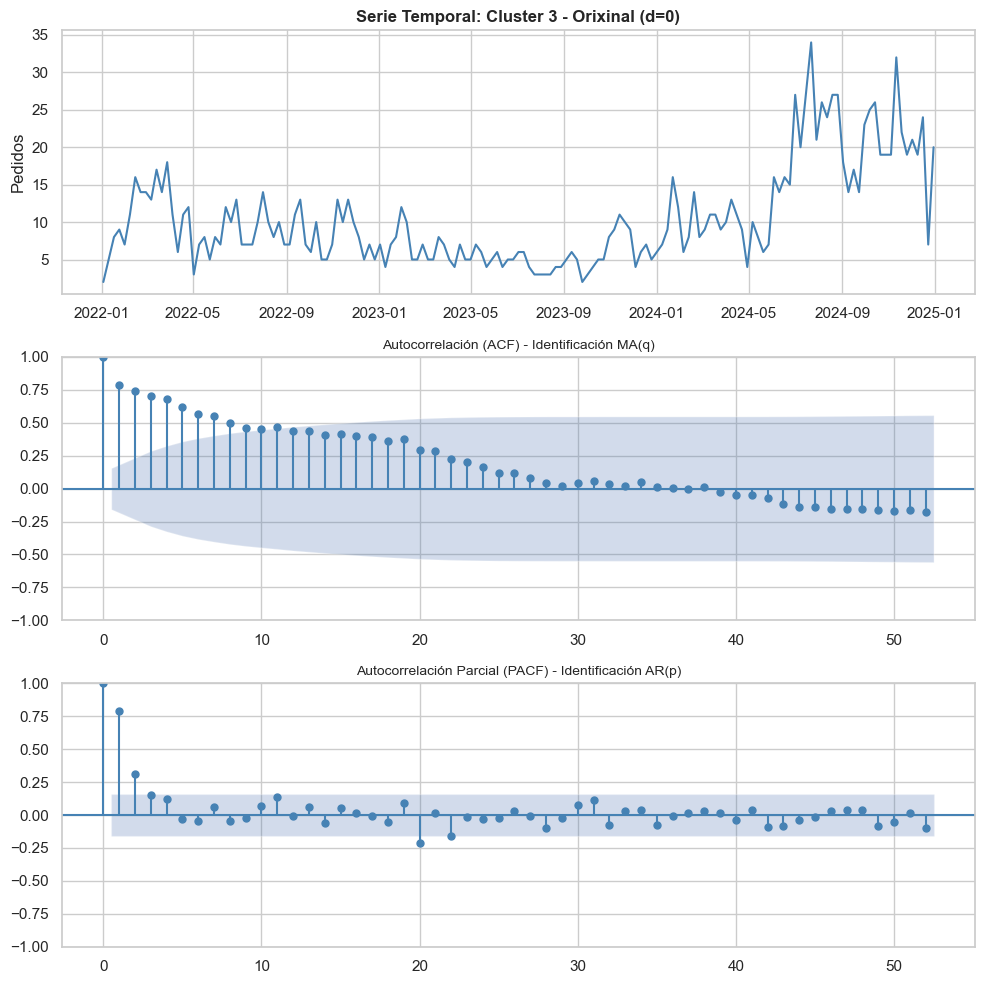

In [76]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

No gráfico secuencial podemos observar un posible problema de heterocedasticidade, ata maio do 2024 a varianza é pequena, mentres que a partir deste momento, ademáis de crecer o nivel medio tamén oscila de forma máis significativa. Polo tanto procederemos a aplicar a transformación log á nosa serie.

In [77]:
modelo = 'Cluster 3'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

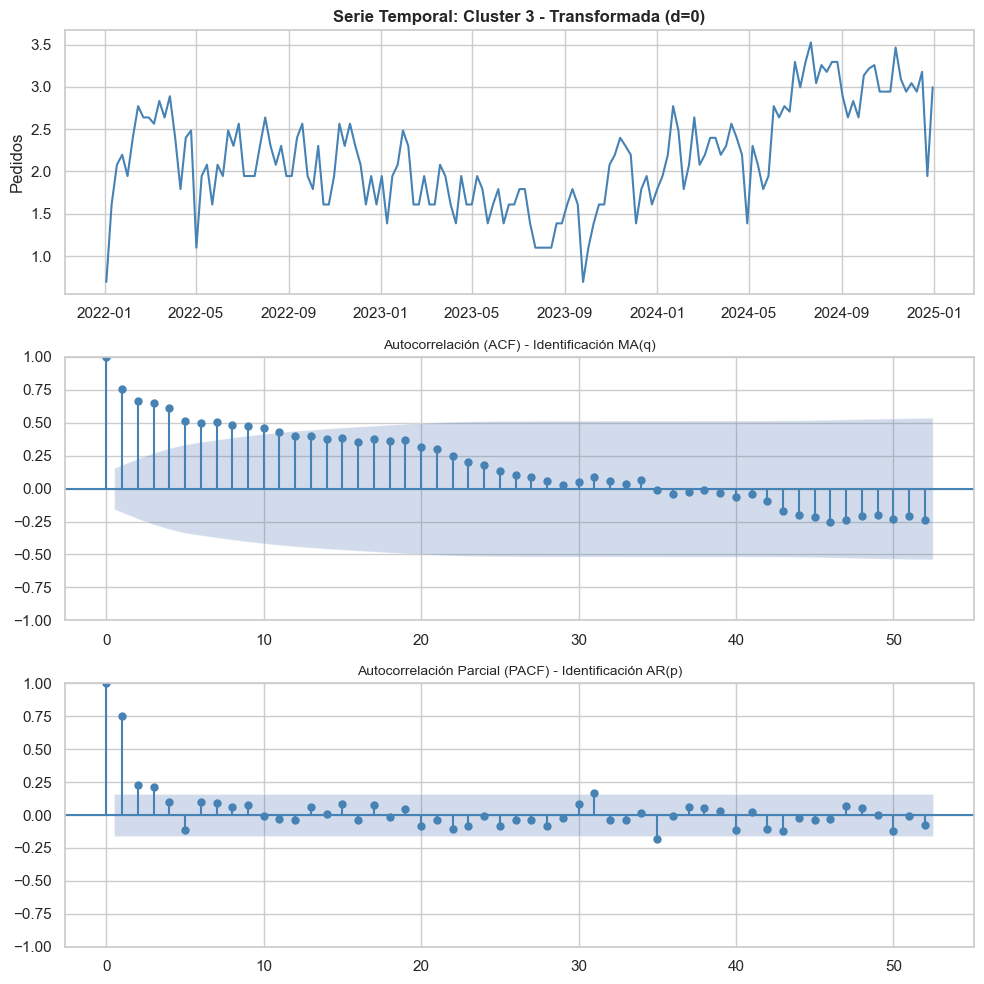

In [78]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Transformada (d=0)"
)

Estando o problema de heterocedasticidade corrixido, seguimos vendo tendencia a partir de maio de 2024 fundamentalmente. Daquela diferenciamos a serie.

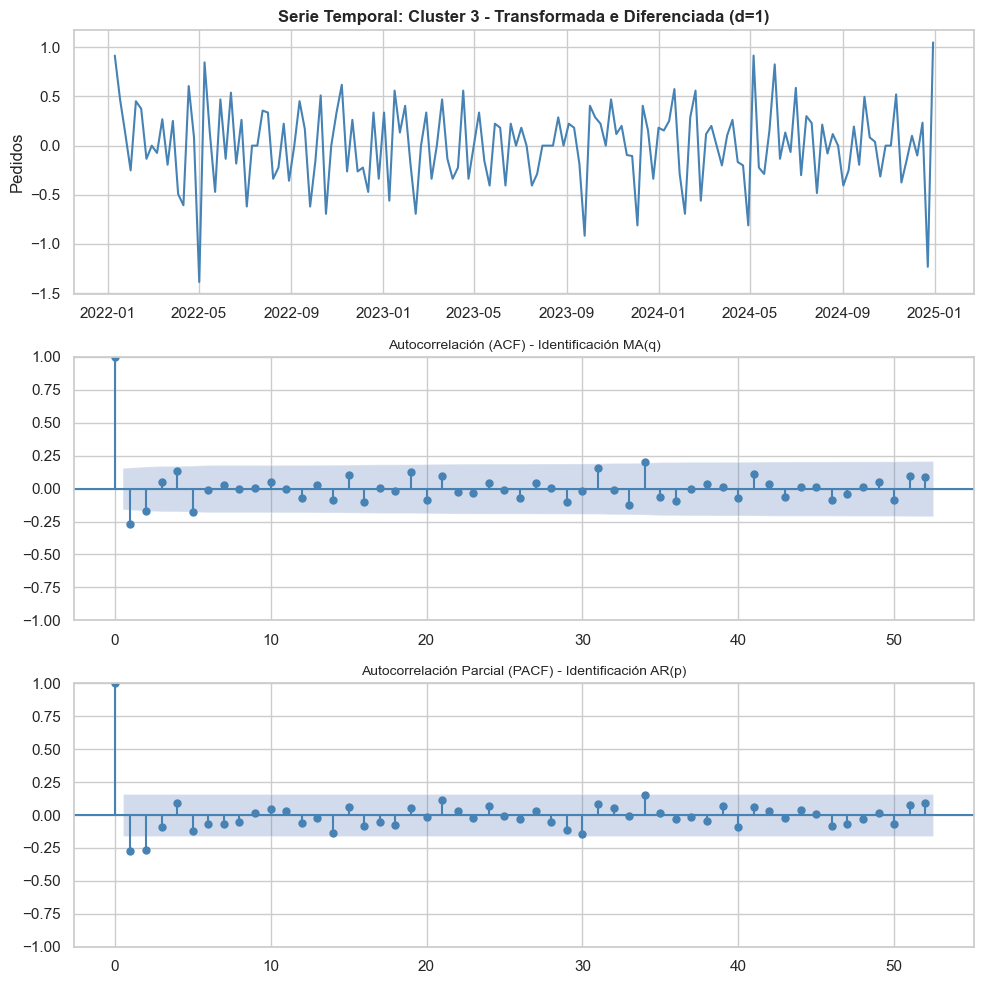

In [79]:
modelo = 'Cluster 3'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Transformada e Diferenciada (d=1)"
)

Unha vez diferenciada a serie transformada, os problemas de tendencia corríxense.  

Daquela, a serie diferenciada pode vir explicada ou ben por un MA(1) ou ben por un AR(2). Así, un modelo para a serie orixinal (transformada) podería ser ARIMA(0,1,1) ou ARIMA(2,1,0).

#### Selección do modelo mediante AICc

In [80]:
modelo = 'Cluster 3'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=163.323, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=152.370, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=139.997, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=161.540, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=138.727, Time=0.16 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=139.095, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=139.898, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=137.963, Time=0.09 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=139.866, Time=0.12 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=140.890, Time=0.24 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=136.543, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=138.431, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=138.459, Time=0.11 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=138.410,

In [81]:
modelo = 'Cluster 3'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (2, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (2, 1, 0) axustado correctamente.
AIC = 137.7299724794667


In [82]:
best_order  = (0,1,2)

#### Detección de atípicos (aditivos e innovativos)

Pasamos agora a facer o contraste de outliers e engadir dita información ao noso modelo:

In [83]:
modelo = 'Cluster 3'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2022-05-02 | t-stat: 3.85 > 3.59
   [Iter 2] Non se atoparon máis atípicos significativos (Max t: 3.31). Fin.
       fecha    t_stat  iter      tipo
0 2022-05-02 -3.850211     1  Negativo
            bf_pre  bf_peak  bf_post  outlier_20220502
semana                                                
2022-01-03       0        0        0                 0
2022-01-10       0        0        0                 0
2022-01-17       0        0        0                 0
2022-01-24       0        0        0                 0
2022-01-31       0        0        0                 0


Un atípico en 02/05/2022.

#### Estimación ou axuste do modelo

In [84]:
modelo = 'Cluster 3'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(0, 1, 2) con 4 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -48.055
Date:                Tue, 13 Jan 2026   AIC                            110.110
Time:                        23:20:13   BIC                            131.323
Sample:                    01-03-2022   HQIC                           118.727
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.2065      0.210      0.984      0.325      -0.205       0.618
bf_peak              0.3512      0.268     

Vemos como os coeficientes correspondentes ao impacto do Black Friday non son significativos. Comezamos eliminando o menos significativo pre-BF:

In [85]:
modelo = 'Cluster 3'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...
✅ Variable 'bf_post' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(0, 1, 2) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -49.475
Date:                Tue, 13 Jan 2026   AIC                            110.950
Time:                        23:20:13   BIC                            129.132
Sample:                    01-03-2022   HQIC                           118.336
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre           

Agora a menos significativa é a variable dummy que capta o efecto do propio BF. Quitámola do modelo:

In [86]:
modelo = 'Cluster 3'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
✅ Variable 'bf_pre' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(0, 1, 2) coas 2 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -49.904
Date:                Tue, 13 Jan 2026   AIC                            109.808
Time:                        23:20:13   BIC                            124.960
Sample:                    01-03-2022   HQIC                           115.963
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak            

In [87]:
modelo = 'Cluster 3'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
✅ Variable 'bf_peak' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(0, 1, 2) coas 1 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -50.346
Date:                Tue, 13 Jan 2026   AIC                            108.691
Time:                        23:20:13   BIC                            120.813
Sample:                    01-03-2022   HQIC                           113.615
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220502 

Todos os coeficientes significativos.

#### Diagnose ou análise dos residuos

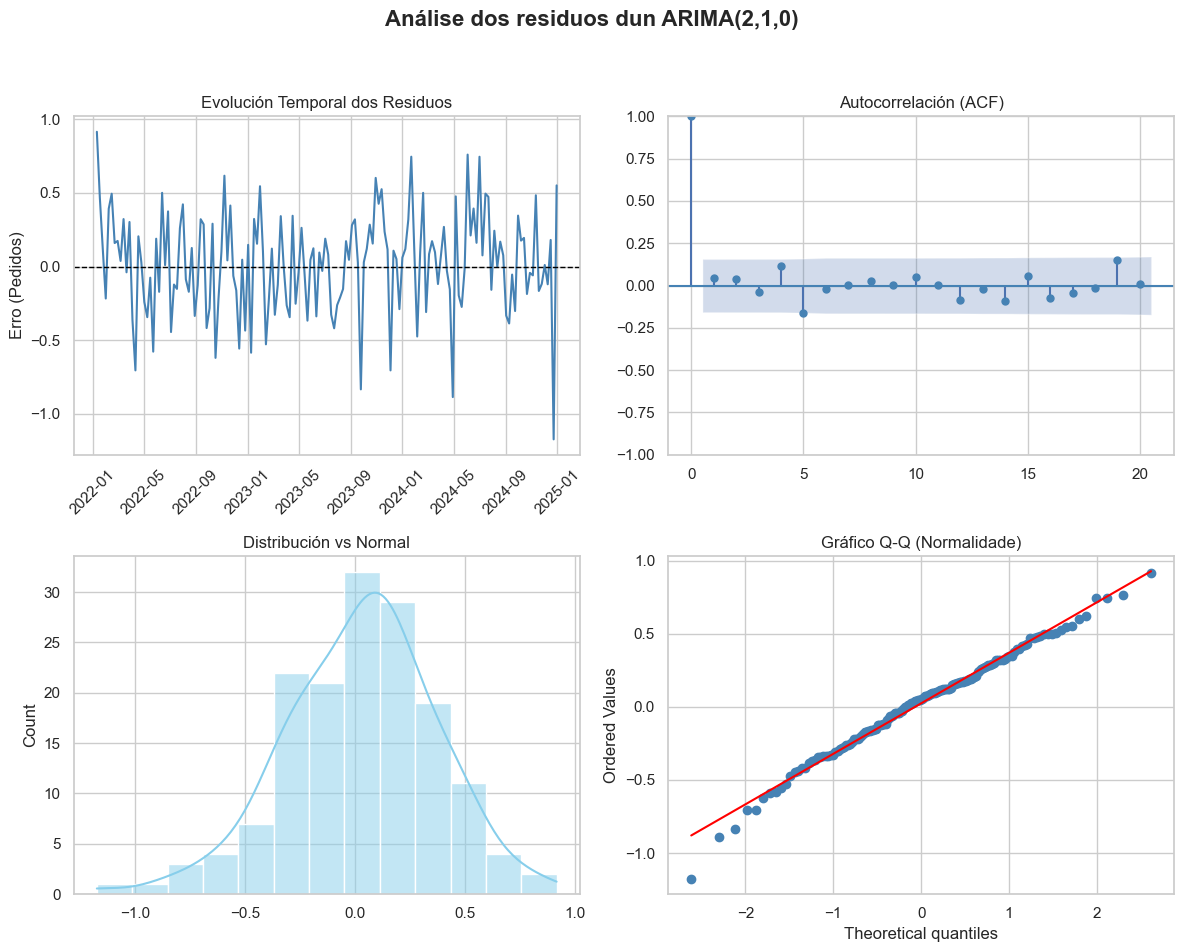


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(2,1,0) ---
1️⃣  Sesgo (Media=0):  p-value = 0.3908 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.3778 ✅ (Aceptamos H0: Residuos normais)
------------------------------------------------------------


In [88]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(2,1,0)')

Graficamente non observamos problemas de correlación ou heterocedasticidade. En relación á normalidade, os residuos presentan certa asimetría co cal é posible que non se vaia cumprir.

In [89]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 2)   Log Likelihood                 -50.346
Date:                Tue, 13 Jan 2026   AIC                            108.691
Time:                        23:20:13   BIC                            120.813
Sample:                    01-03-2022   HQIC                           113.615
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220502    -1.0876      0.358     -3.037      0.002      -1.790      -0.386
ma.L1               -0.4569      0.088     -5.219      0.000      -0.628      -0.285
ma.L2               -0.2158      0.085     -2.539      0.011      -0.382      -0.049
sigma2               0.1129      0.012      9.607      0.000       0.090       0.136
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 6.19
Prob(Q):                              0.81   Prob(JB):                         0.05
Heteroskedasticity (H):               1.29   Skew:                            -0.42
Prob(H) (two-sided):                  0.37   Kurtosis:                         3.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Modelo válido con innovacións non gaussianas.

#### Predicións

Da mesma forma que no cluster 2, axustamos o modelo para os datos transformados (log), co cal á hora de predecir debemos facer a transformación inversa (exp):

--- 🔮 VALIDACIÓN ROLLING WINDOW: Cluster 3 ---
   Variables en modelo: 1
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 2)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...


   > Semana 10/38: Pred=3.23
   > Semana 20/38: Pred=3.09
   > Semana 30/38: Pred=2.68


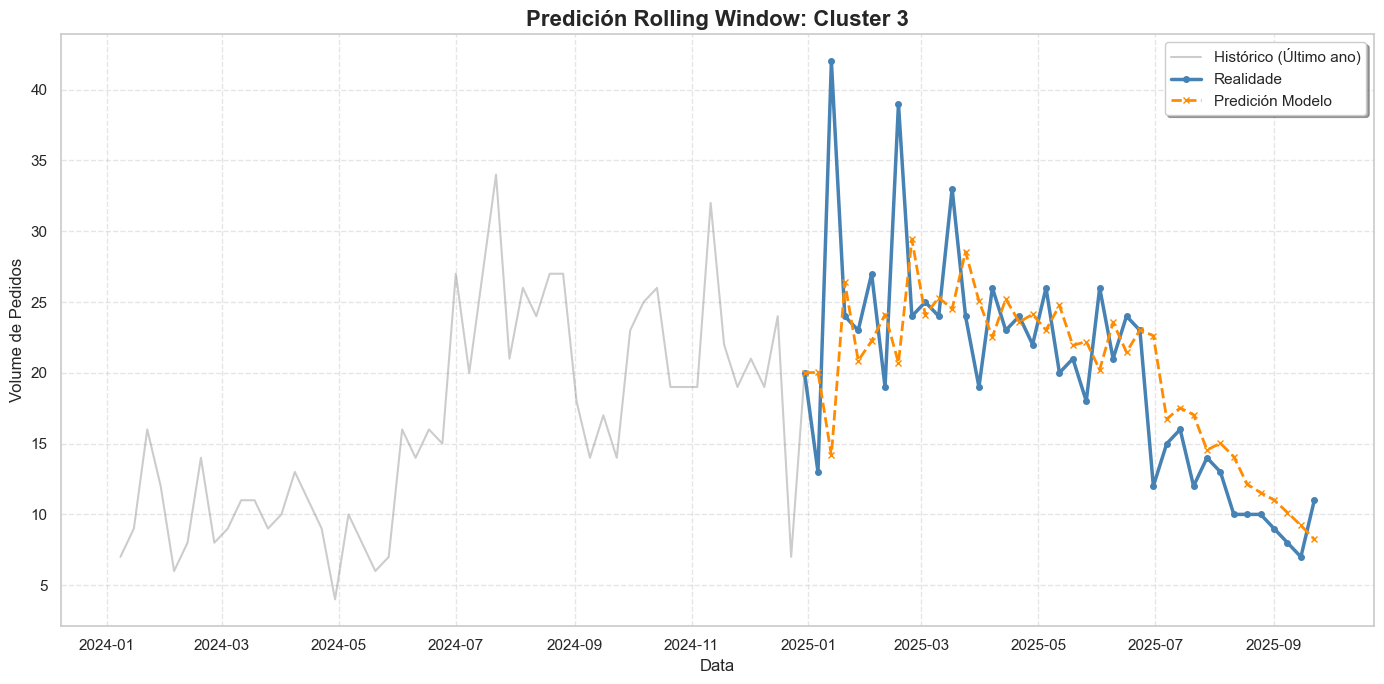

In [90]:
modelo = 'Cluster 3'
print(f"--- 🔮 VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW
# Usamos a función 'arimax' porque confirmamos que NON hai estacionalidade
preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], # Pasamos o Test coas columnas corrixidas
    order=datos_arima[modelo]['order'],
    trend='n',             # Sen tendencia (xa diferenciamos ou non é significativa)
    verbose=True           # Para ver o progreso semana a semana
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=preds_rolling,
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [91]:
modelo = 'Cluster 3'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo (comparas contra o valor da semana anterior)
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)

--- 📊 AVALIACIÓN: Cluster 3 (Rolling) ---
MAE:  4.33
RMSE: 6.67
MAPE: 22.01%
MASE: 1.44 (Non Estacional (m=1))
⚠️ CONCLUSIÓN: O modelo non supera ao benchmark (MASE > 1).


Rendemento peor aos datos orixinais.

Neste último sector obtemos un rendemento bastante peor: MAPE = 20.78% e MASE = 1.38. Isto débese principalmente aos tres primeiros meses do 2025, onde se observan semanas con volume de envíos claramente superior ao habitual nos clientes deste sector. **Interesa ver se os datos destas semanas se deben a algún feito coñecido**

En particular, podemos calcular as métricas prescindindo do primeiro trimestre do ano (onde se ven comportamentos anómalos), para avaliar así o rendemento do modelo no período de comportamento máis estable do sector.

In [92]:
modelo = 'Cluster 3'

print(f"--- 📉 ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: {modelo} ---")

# 1. Definimos a data de corte (Inicio do Q2)
start_date_Q2 = '2025-04-01'

# 2. Filtramos as series (Reutilizamos as variables que xa tes en memoria)
# y_test: A realidade completa
# preds_rolling: A predición completa (xa invertida se usaches logs)
y_true_clean = datos_arima[modelo]['y_test'].loc[start_date_Q2:]
y_pred_clean = datos_arima[modelo]['predicions'].loc[start_date_Q2:]

print(f"   Datos totais 2025: {len(datos_arima[modelo]['y_test'])} semanas")
print(f"   Datos analizados (Abr-Dec): {len(y_true_clean)} semanas")

if len(y_true_clean) > 0:
    # 3. Cálculo das Métricas Filtradas usando a túa función
    # TRUCO MESTRE: Pasamos 'y_train' completo. 
    # Por que? Porque o MASE compara o erro do test contra a historia do train.
    # O histórico non cambia aínda que miremos menos meses de test.
    metricas_clean = ft.calcular_metricas_completas(
        y_true=y_true_clean,
        y_pred=y_pred_clean,
        y_train=datos_arima[modelo]['y_train'], # Orixinal completo
        m=1, # Ou 52 se fose o Global/Cluster 1
        etiqueta=f"{modelo} (Sen Q1)"
    )
    
    # 4. Comparativa Visual (Opcional pero queda moi ben)
    print("\n   --- MELLORA OBTIDA AO ELIMINAR Q1 ---")
    # 'metricas' é o dicionario que calculaches no paso anterior co total
    for key in ['MAE', 'RMSE', 'MAPE', 'MASE']:
        valor_total = metricas[key]
        valor_clean = metricas_clean[key]
        diff = valor_total - valor_clean
        
        # Se diff > 0, o erro baixou (Mellora)
        # Se diff < 0, o erro subiu (Empeora)
        estado = "✅ Mellora" if diff > 0 else "❌ Empeora"
        print(f"   {key}: {valor_total:.2f} -> {valor_clean:.2f} | Dif: {diff:.2f} ({estado})")

else:
    print("⚠️ Erro: Non quedan datos despois do corte.")

datos_arima[modelo]['metricas'] = metricas_clean

--- 📉 ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: Cluster 3 ---
   Datos totais 2025: 38 semanas
   Datos analizados (Abr-Dec): 25 semanas
--- 📊 AVALIACIÓN: Cluster 3 (Sen Q1) ---
MAE:  2.82
RMSE: 3.53
MAPE: 19.88%
MASE: 0.94 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).

   --- MELLORA OBTIDA AO ELIMINAR Q1 ---
   MAE: 4.33 -> 2.82 | Dif: 1.52 (✅ Mellora)
   RMSE: 6.67 -> 3.53 | Dif: 3.14 (✅ Mellora)
   MAPE: 22.01 -> 19.88 | Dif: 2.13 (✅ Mellora)
   MASE: 1.44 -> 0.94 | Dif: 0.51 (✅ Mellora)


Resultados peores.

Gardamos a información da análise de intervención e atípicos para o Prophet:

In [93]:
modelo = 'Cluster 3'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n✅ Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Cluster 3 ---
   💾 Empaquetando datos de Cluster 3 para Prophet...

✅ Datos exportados para Cluster 3.
   Dimensións: (195, 3)
   Columnas incluídas: ['semana', 'n_pedidos', 'outlier_20220502']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  outlier_20220502
190 2025-08-25       10.0                 0
191 2025-09-01        9.0                 0
192 2025-09-08        8.0                 0
193 2025-09-15        7.0                 0
194 2025-09-22       11.0                 0


#### Rendemento dos modelos por cluster

Imos calcular un promedio ponderado dos tres clusters para ter unhas medidas de rendemento xerais e podamos comparar se é mellor considerar un único modelo de predición para todos os clientes (menos interpretable) ou ben é mellor diferenciar entre os distintos clusters. Ten máis sentido esto segundo posto que, no caso contrario, estamos a predecir o mesmo volume de envíos para todos os clientes, mentres que diferenciando entre clusters, en función do tipo de cliente (cluster ao que pertence), teremos unha predición distinta.

Unha primeira media ponderada podería calcularse tendo en conta a proporción de envíos que representan cada un dos clusters do volume total de pedidos.

--- ⚖️ COMPARATIVA FINAL ROBUSTA: GLOBAL vs PONDERADA ---

--- 🏆 RESULTADOS FINAIS ---
Métrica    | Modelo Único | Suma Clusters | Mellora
--------------------------------------------------
MAE        | 7.07         | 3.26         | 3.81
RMSE       | 9.84         | 4.39         | 5.45
MAPE       | 7.81       % | 11.56      % | -3.75%
MASE       | 0.54         | 0.56         | -0.02


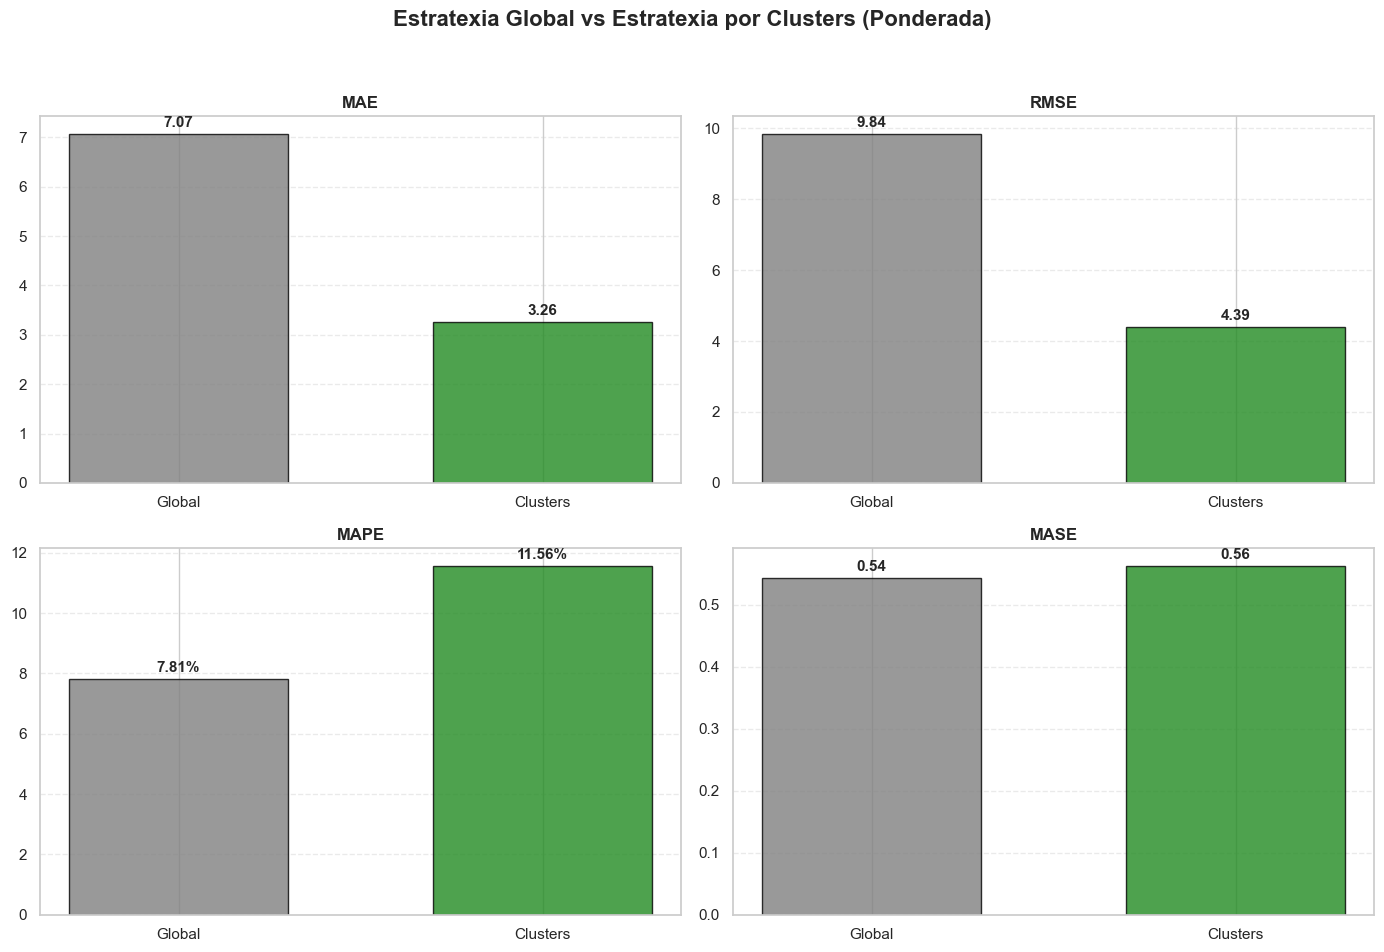

In [94]:
print("--- ⚖️ COMPARATIVA FINAL ROBUSTA: GLOBAL vs PONDERADA ---")

# 1. CÁLCULO DOS PESOS REALES (Automático)
# Usamos o dicionario 'datos' orixinal que ten os DataFrames crus coa columna 'n_pedidos'
volumen_total = datos['Global']['n_pedidos'].sum()

clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
lista_metricas = []

for c in clusters:
    # A. Recuperamos o volume para o peso
    vol_cluster = datos[c]['n_pedidos'].sum()
    peso = vol_cluster / volumen_total
    
    # B. Recuperamos as métricas que gardaches no paso anterior
    # Xa non hai "if c == 'Cluster 3'", porque xa gardaste a versión correcta dentro do dicionario
    m = datos_arima[c]['metricas']
    
    # C. Engadimos á lista
    lista_metricas.append({
        'Cluster': c,
        'MAE': m['MAE'],
        'RMSE': m['RMSE'],
        'MAPE': m['MAPE'],
        'MASE': m['MASE'],
        'Peso': peso
    })

# Convertemos a DataFrame para operar fácil
df_comp = pd.DataFrame(lista_metricas)

# 2. CÁLCULO PONDERADO (Vectorial)
# Suma(Métrica * Peso) para cada columna
w_mae  = (df_comp['MAE'] * df_comp['Peso']).sum()
w_rmse = (df_comp['RMSE'] * df_comp['Peso']).sum()
w_mape = (df_comp['MAPE'] * df_comp['Peso']).sum()
w_mase = (df_comp['MASE'] * df_comp['Peso']).sum()

# 3. RECUPERAR O GLOBAL
# Tamén o lemos do dicionario
met_global = datos_arima['Global']['metricas']

# 4. TABOA DE RESULTADOS
print("\n--- 🏆 RESULTADOS FINAIS ---")
print(f"{'Métrica':<10} | {'Modelo Único':<12} | {'Suma Clusters':<12} | {'Mellora'}")
print("-" * 50)
print(f"{'MAE':<10} | {met_global['MAE']:<12.2f} | {w_mae:<12.2f} | {met_global['MAE'] - w_mae:.2f}")
print(f"{'RMSE':<10} | {met_global['RMSE']:<12.2f} | {w_rmse:<12.2f} | {met_global['RMSE'] - w_rmse:.2f}")
print(f"{'MAPE':<10} | {met_global['MAPE']:<11.2f}% | {w_mape:<11.2f}% | {met_global['MAPE'] - w_mape:.2f}%")
print(f"{'MASE':<10} | {met_global['MASE']:<12.2f} | {w_mase:<12.2f} | {met_global['MASE'] - w_mase:.2f}")

# 5. VISUALIZACIÓN GRÁFICA
metrics_names = ['MAE', 'RMSE', 'MAPE', 'MASE']
vals_global = [met_global['MAE'], met_global['RMSE'], met_global['MAPE'], met_global['MASE']]
vals_weighted = [w_mae, w_rmse, w_mape, w_mase]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Estratexia Global vs Estratexia por Clusters (Ponderada)', fontsize=16, fontweight='bold')
axes_flat = axes.flatten()
colors = ['gray', 'forestgreen']

for i, metric in enumerate(metrics_names):
    ax = axes_flat[i]
    bars = ax.bar(['Global', 'Clusters'], [vals_global[i], vals_weighted[i]], 
                  color=colors, alpha=0.8, edgecolor='black', width=0.6)
    
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    fmt = '%.2f%%' if metric == 'MAPE' else '%.2f'
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Modelos Prophet

Probaremos agora cunha aproximación diferente, axustando os modelos Prophet. Estos son uns modelos aditivos de series temporais con compoñentes interpretables:

$y(t) = g(t) + s(t) + h(t) + \epsilon_t$,

onde

$g(t)$ é a tendencia.

$s(t)$ é a estacionalidade.

$h(t)$ é o efecto dos festivos ou eventos especiais.

$\epsilon_t$ o erro.

Comezaremos aplicando ditos modelos ao conxunto total dos nosos datos, e posteriormente a cada cluster por separado, vendo se melloramos as nosas predicións. 

Como estes modelos nos permiten incluír o efecto de ebentos especiais, debemos crear un Dataframe que conteña as datas do **Black Friday**. Como no EDA observamos que o efecto de dita celebración se extende a todo o mes de novembro (a comezos do mes habitúa a aumentar o volume de pedidos), incluímos unha fiestra para indicar que o efecto comeza 3 semanas antes da semana onde se celebra o **Black Friday**.

In [95]:
# LISTA DOS FESTIVOS:
festivos = [
    '2022-04-14', '2022-04-15', '2022-04-18',
    '2022-05-26', '2023-04-06', '2023-04-07', '2023-04-10',
    '2023-05-18', '2024-03-28', '2024-03-29', '2024-04-01',
    '2024-05-20', '2025-04-17', '2025-04-18',
    '2025-04-21', '2025-05-29'
]
df_festivos_prophet = ft.preparar_festivos_prophet(festivos)
# Dicionario para gardar resultados:
resultados_prophet = {}

Modifiquemos os nosos datos de entrenamento e test para que sexan válidos para o modelo Prophet. Cómpre sinalar que dito modelo precisa que incorporemos os datos mediante un dataframe con dúas columnas $ds$ e $y$. A primeira debe ser datos de datas e a segunda a nosa variable de interese.

Unha vez creados os dataframes da forma que precisa o modelo Prophet, pasamos a construír un dataframe que conteña a información sobre os festivos a ter en conta na nosa base de datos. Comezamos cargando os festivos que engadimos no EDA e, como os nosos datos son semanais, pasámolos ao luns da semana correspondente. Ademáis, debemos ter en conta que, ao ter datos semanais, os efectos dalgúns festivos captúranse directamente coa estacionalidade anual, co cal só debemos incluír aqueles que que cambian de data dependendo do ano. 

Engadimos agora a información sobre o **Black Friday**. En particular, apoiarémonos na análise de intervención feita durante o axuste dos modelos ARIMA. Isto é, non en tódolos clusters o efecto do Black Friday era o mesmo. Daquela recuperamos a construción das variables dummys creadas anteriormente.

### Modelo xeral

In [96]:
modelo = 'Global'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Global
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (5): ['bf_pre', 'bf_peak', 'bf_post']...
   Variables exóxenas detectadas (5): ['bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']


In [97]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")


--- 🔧 TUNING: Global ---
🚀 Iniciando Grid Search con 64 combinacións...


23:21:12 - cmdstanpy - INFO - Chain [1] start processing
23:21:12 - cmdstanpy - INFO - Chain [1] done processing
23:21:13 - cmdstanpy - INFO - Chain [1] start processing
23:21:13 - cmdstanpy - INFO - Chain [1] start processing
23:21:13 - cmdstanpy - INFO - Chain [1] start processing
23:21:13 - cmdstanpy - INFO - Chain [1] done processing
23:21:13 - cmdstanpy - INFO - Chain [1] start processing
23:21:13 - cmdstanpy - INFO - Chain [1] start processing
23:21:13 - cmdstanpy - INFO - Chain [1] start processing
23:21:13 - cmdstanpy - INFO - Chain [1] done processing
23:21:13 - cmdstanpy - INFO - Chain [1] done processing
23:21:13 - cmdstanpy - INFO - Chain [1] done processing
23:21:13 - cmdstanpy - INFO - Chain [1] done processing
23:21:14 - cmdstanpy - INFO - Chain [1] done processing
23:21:14 - cmdstanpy - INFO - Chain [1] start processing
23:21:14 - cmdstanpy - INFO - Chain [1] done processing
23:21:15 - cmdstanpy - INFO - Chain [1] start processing
23:21:15 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/64: RMSE=21.5316


23:21:24 - cmdstanpy - INFO - Chain [1] start processing
23:21:24 - cmdstanpy - INFO - Chain [1] start processing
23:21:24 - cmdstanpy - INFO - Chain [1] start processing
23:21:24 - cmdstanpy - INFO - Chain [1] start processing
23:21:24 - cmdstanpy - INFO - Chain [1] start processing
23:21:24 - cmdstanpy - INFO - Chain [1] start processing
23:21:24 - cmdstanpy - INFO - Chain [1] done processing
23:21:24 - cmdstanpy - INFO - Chain [1] done processing
23:21:24 - cmdstanpy - INFO - Chain [1] done processing
23:21:24 - cmdstanpy - INFO - Chain [1] done processing
23:21:24 - cmdstanpy - INFO - Chain [1] done processing
23:21:24 - cmdstanpy - INFO - Chain [1] done processing
23:21:24 - cmdstanpy - INFO - Chain [1] start processing
23:21:24 - cmdstanpy - INFO - Chain [1] done processing
23:21:25 - cmdstanpy - INFO - Chain [1] start processing
23:21:25 - cmdstanpy - INFO - Chain [1] start processing
23:21:25 - cmdstanpy - INFO - Chain [1] start processing
23:21:25 - cmdstanpy - INFO - Chain [1

   > Combinación 10/64: RMSE=21.0570


...

23:23:13 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing
23:23:13 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing
23:23:13 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing
23:23:13 - cmdstanpy - INFO - Chain [1] start processing
23:23:13 - cmdstanpy - INFO - Chain [1] done processing
23:23:15 - cmdstanpy - INFO - Chain [1] start processing
23:23:15 - cmdstanpy - INFO - Chain [1] start processing
23:23:15 - cmdstanpy - INFO - Chain [1] start processing
23:23:15 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=20.0874


23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
23:23:28 - cmdstanpy - INFO - Chain [1] done processing
23:23:28 - cmdstanpy - INFO - Chain [1] start processing
23:23:28 - cmdstanpy - INFO - Chain [1] done processing
23:23:29 - cmdstanpy - INFO - Chain [1] start processing
23:23:30 - cmdstanpy - INFO - Chain [1] start processing
23:23:30 - cmdstanpy - INFO - Chain [1] start processing
23:23:30 - cmdstanpy - INFO - Chain [1


✅ Grid Search Completado.
   Mellor RMSE: 19.1540
   Parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}


23:23:36 - cmdstanpy - INFO - Chain [1] done processing


In [98]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'],  # Usamos os que gañaron no tuning
    verbose=True
)

23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing
23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing
23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing



--- 🔮 ROLLING WINDOW: Global ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing
23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing
23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing
23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing
23:25:00 - cmdstanpy - INFO - Chain [1] start processing
23:25:00 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=110.14


23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] start processing
23:25:01 - cmdstanpy - INFO - Chain [1] done processing
23:25:01 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=111.13


23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=88.92


23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing
23:25:02 - cmdstanpy - INFO - Chain [1] start processing
23:25:02 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Global ---


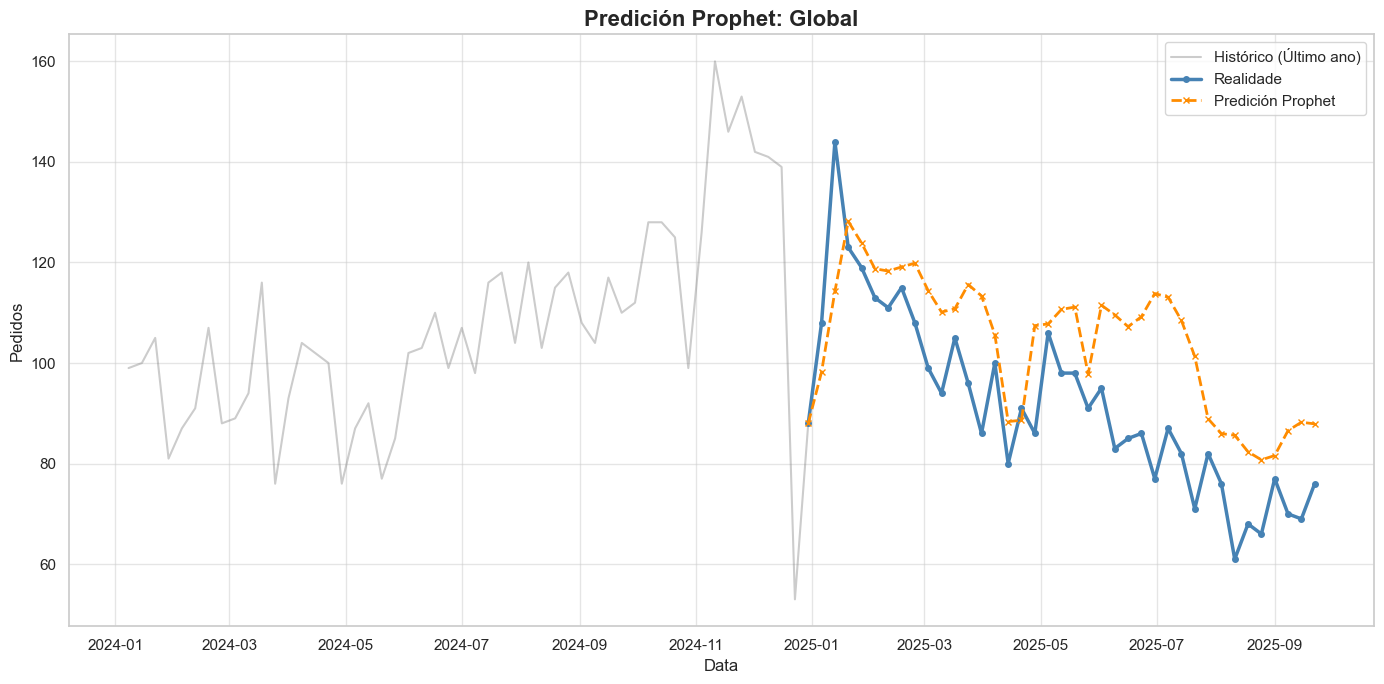

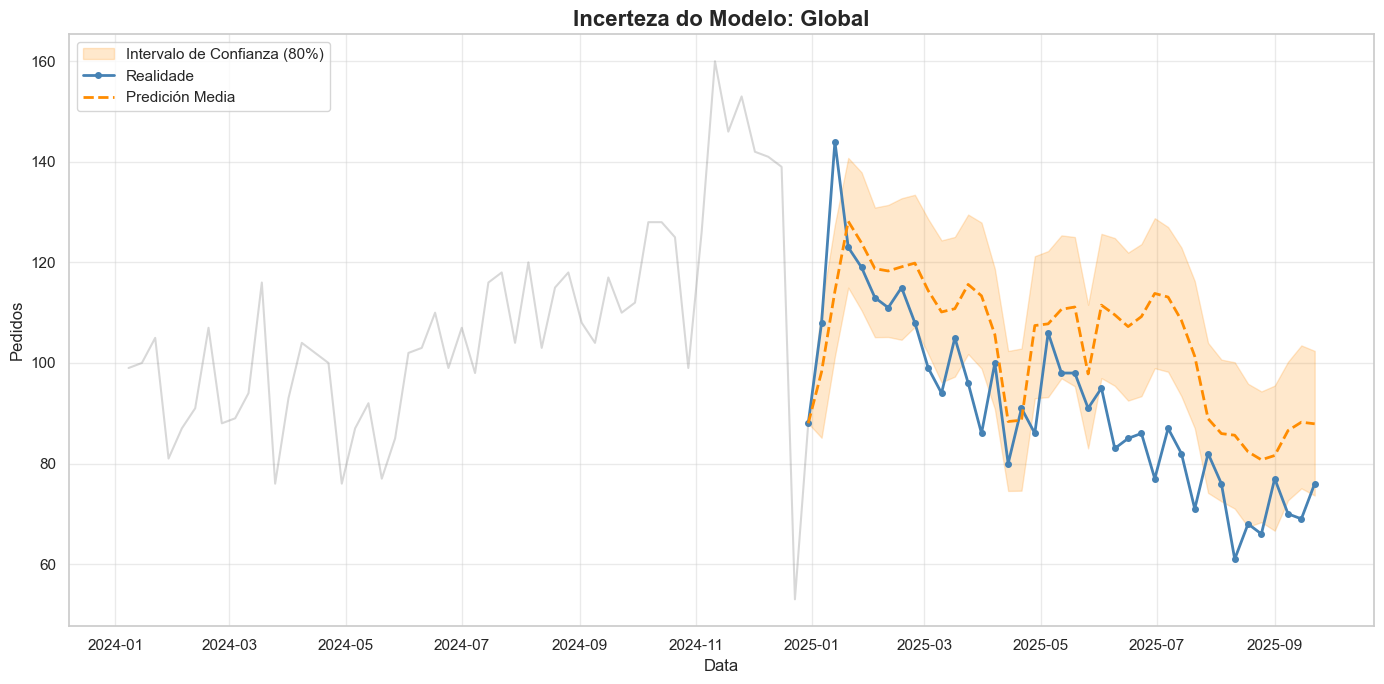

In [99]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

E avaliamos o rendemento do modelo:

Neste caso, como temos estacionalidade anual, debemos modificar a función que calcula o MASE posto que agora temos que comparar coa predición naïve do valor $x_t$ co valor observado $s=52$ instantes previos $x_{t-52}$, polo tanto debemos cambiar o denominador de dita medida do erro:

In [100]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Global ---
MAE:  14.90
RMSE: 17.43
MAPE: 17.57%
MASE: 0.71 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos como o MAPE = 18.70% e o MASE = 0.73, co cal o modelo predice mellor ca o naïve estacional (predecir o valor dunha semana como a do ano previo). 

Vemos graficamente as distintas compoñentes do modelo. Como aplicamos a metodoloxía $\textit{Rolling-Window}$, temos axustado 39 modelos (un por semana de horizonte). Así, representaremos as compoñentes do último modelo por ser o máis actual (se por exemplo queremos usar o modelo para semanas futuras este será o de partida):

23:25:17 - cmdstanpy - INFO - Chain [1] start processing
23:25:17 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


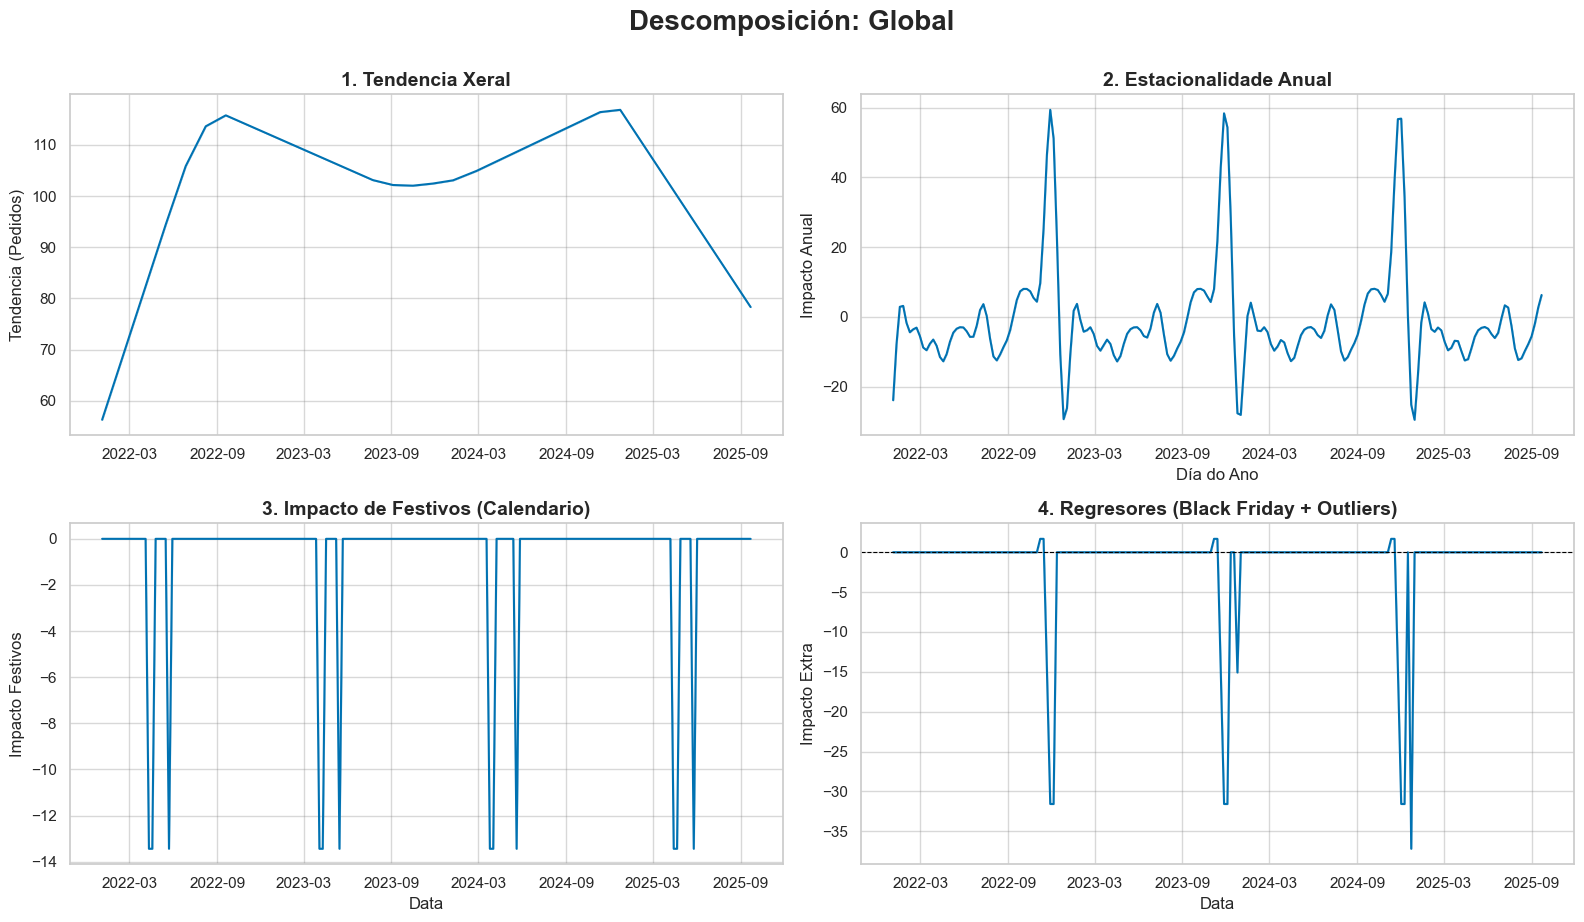

In [101]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Da mesma forma que fixemos para os modelos ARIMA, podemos pensar agora en axustar un modelo para cada cluster de clientes e ver se desta forma construímos un modelo mellor.

### Cluster 1:

Debemos repetir o proceso anterior para os datos do cluster 1, que recordemos que representaba aos clientes de transporte, retail e electrónica.

In [102]:
modelo = 'Cluster 1'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 1
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (3): ['bf_peak', 'bf_post', 'outlier_20231225']...
   Variables exóxenas detectadas (3): ['bf_peak', 'bf_post', 'outlier_20231225']


In [103]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")

23:25:21 - cmdstanpy - INFO - Chain [1] start processing
23:25:21 - cmdstanpy - INFO - Chain [1] done processing



--- 🔧 TUNING: Cluster 1 ---
🚀 Iniciando Grid Search con 64 combinacións...


23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:23 - cmdstanpy - INFO - Chain [1] start processing
23:25:23 - cmdstanpy - INFO - Chain [1] done processing
23:25:25 - cmdstanpy - INFO - Chain [1] start processing
23:25:25 - cmdstanpy - INFO - Chain [1] start processing
23:25:25 - cmdstanpy - INFO - Chain [1] start processing
23:25:25 - cmdstanpy - INFO - Chain [1

   > Combinación 5/64: RMSE=19.6001


23:25:33 - cmdstanpy - INFO - Chain [1] start processing
23:25:33 - cmdstanpy - INFO - Chain [1] start processing
23:25:33 - cmdstanpy - INFO - Chain [1] done processing
23:25:33 - cmdstanpy - INFO - Chain [1] done processing
23:25:33 - cmdstanpy - INFO - Chain [1] start processing
23:25:33 - cmdstanpy - INFO - Chain [1] start processing
23:25:33 - cmdstanpy - INFO - Chain [1] start processing
23:25:33 - cmdstanpy - INFO - Chain [1] done processing
23:25:33 - cmdstanpy - INFO - Chain [1] done processing
23:25:33 - cmdstanpy - INFO - Chain [1] start processing
23:25:33 - cmdstanpy - INFO - Chain [1] done processing
23:25:33 - cmdstanpy - INFO - Chain [1] done processing
23:25:33 - cmdstanpy - INFO - Chain [1] start processing
23:25:33 - cmdstanpy - INFO - Chain [1] done processing
23:25:34 - cmdstanpy - INFO - Chain [1] start processing
23:25:34 - cmdstanpy - INFO - Chain [1] done processing
23:25:34 - cmdstanpy - INFO - Chain [1] start processing
23:25:34 - cmdstanpy - INFO - Chain [1]

...

23:27:19 - cmdstanpy - INFO - Chain [1] start processing
23:27:19 - cmdstanpy - INFO - Chain [1] start processing
23:27:19 - cmdstanpy - INFO - Chain [1] start processing
23:27:19 - cmdstanpy - INFO - Chain [1] done processing
23:27:19 - cmdstanpy - INFO - Chain [1] start processing
23:27:19 - cmdstanpy - INFO - Chain [1] done processing
23:27:19 - cmdstanpy - INFO - Chain [1] start processing
23:27:19 - cmdstanpy - INFO - Chain [1] start processing
23:27:19 - cmdstanpy - INFO - Chain [1] done processing
23:27:19 - cmdstanpy - INFO - Chain [1] done processing
23:27:19 - cmdstanpy - INFO - Chain [1] done processing
23:27:20 - cmdstanpy - INFO - Chain [1] done processing
23:27:20 - cmdstanpy - INFO - Chain [1] start processing
23:27:20 - cmdstanpy - INFO - Chain [1] done processing
23:27:21 - cmdstanpy - INFO - Chain [1] start processing
23:27:21 - cmdstanpy - INFO - Chain [1] start processing
23:27:21 - cmdstanpy - INFO - Chain [1] start processing
23:27:21 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=14.8700


23:27:32 - cmdstanpy - INFO - Chain [1] start processing
23:27:32 - cmdstanpy - INFO - Chain [1] start processing
23:27:32 - cmdstanpy - INFO - Chain [1] start processing
23:27:32 - cmdstanpy - INFO - Chain [1] start processing
23:27:32 - cmdstanpy - INFO - Chain [1] done processing
23:27:32 - cmdstanpy - INFO - Chain [1] done processing
23:27:32 - cmdstanpy - INFO - Chain [1] start processing
23:27:32 - cmdstanpy - INFO - Chain [1] done processing
23:27:32 - cmdstanpy - INFO - Chain [1] done processing
23:27:32 - cmdstanpy - INFO - Chain [1] start processing
23:27:32 - cmdstanpy - INFO - Chain [1] done processing
23:27:32 - cmdstanpy - INFO - Chain [1] done processing
23:27:32 - cmdstanpy - INFO - Chain [1] start processing
23:27:33 - cmdstanpy - INFO - Chain [1] done processing
23:27:34 - cmdstanpy - INFO - Chain [1] start processing
23:27:34 - cmdstanpy - INFO - Chain [1] start processing
23:27:35 - cmdstanpy - INFO - Chain [1] done processing
23:27:35 - cmdstanpy - INFO - Chain [1]


✅ Grid Search Completado.
   Mellor RMSE: 13.6500
   Parámetros: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}


23:27:41 - cmdstanpy - INFO - Chain [1] done processing


In [104]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], # Usamos os que gañaron no tuning
    verbose=True
)

23:33:04 - cmdstanpy - INFO - Chain [1] start processing
23:33:04 - cmdstanpy - INFO - Chain [1] done processing
23:33:04 - cmdstanpy - INFO - Chain [1] start processing
23:33:04 - cmdstanpy - INFO - Chain [1] done processing
23:33:04 - cmdstanpy - INFO - Chain [1] start processing
23:33:04 - cmdstanpy - INFO - Chain [1] done processing



--- 🔮 ROLLING WINDOW: Cluster 1 ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


23:33:04 - cmdstanpy - INFO - Chain [1] start processing
23:33:04 - cmdstanpy - INFO - Chain [1] done processing
23:33:04 - cmdstanpy - INFO - Chain [1] start processing
23:33:04 - cmdstanpy - INFO - Chain [1] done processing
23:33:04 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=29.30


23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:05 - cmdstanpy - INFO - Chain [1] start processing
23:33:05 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=26.85


23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1]

   > Semana 30/38: Pred=18.29


23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:06 - cmdstanpy - INFO - Chain [1] start processing
23:33:06 - cmdstanpy - INFO - Chain [1] done processing
23:33:07 - cmdstanpy - INFO - Chain [1] start processing
23:33:07 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Cluster 1 ---


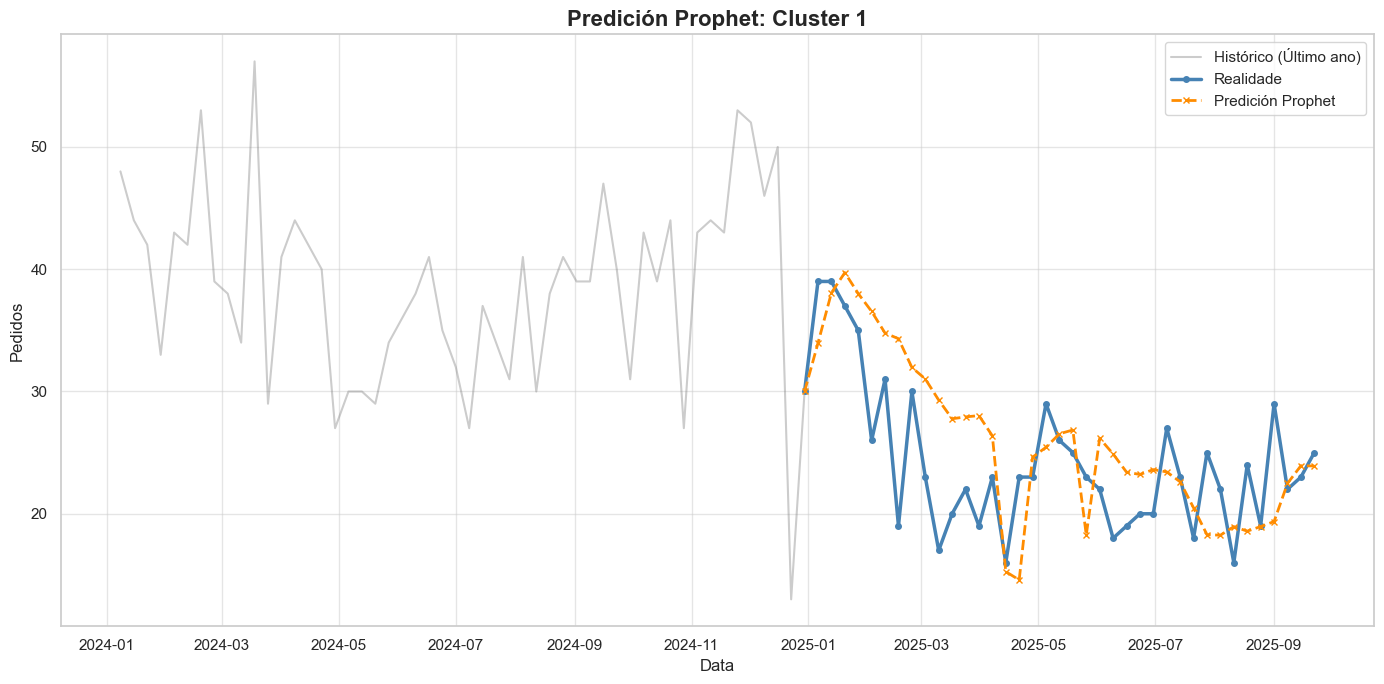

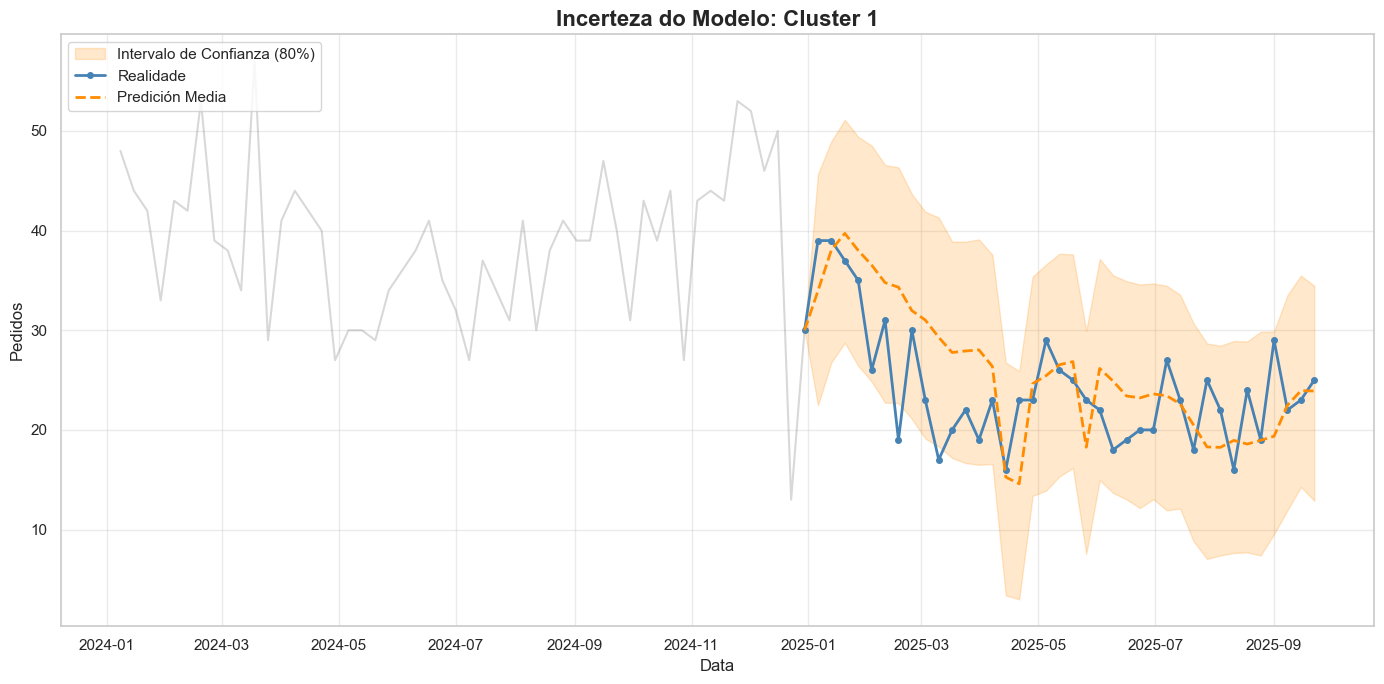

In [105]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [106]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Cluster 1 ---
MAE:  4.50
RMSE: 5.72
MAPE: 20.24%
MASE: 0.30 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos como neste caso o MAPE é lixeiramente superior (40.44%) mais o MASE é bastante pequeno (0.62). 

23:33:17 - cmdstanpy - INFO - Chain [1] start processing
23:33:17 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


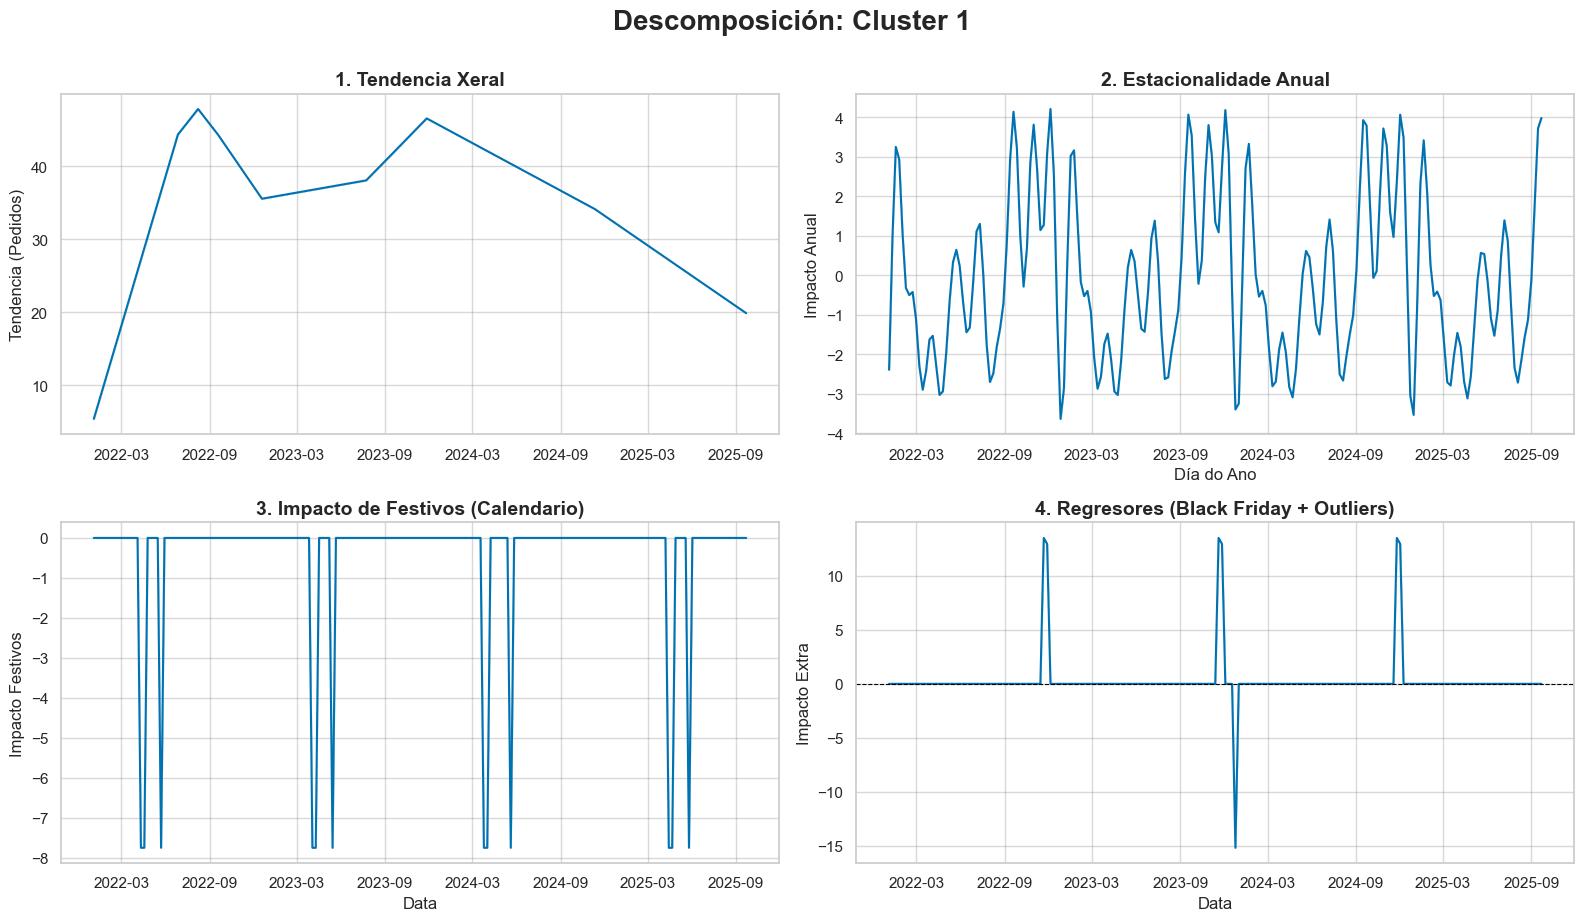

In [107]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Representemos as compoñentes do modelo (o último axutado no Rolling-Window)

### Cluster 2

Facemos o propio para os clientes do cluster 2, que estaba formado polos clientes de paquetería e froita:

In [108]:
modelo = 'Cluster 2'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 2
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']...
   Variables exóxenas detectadas (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']


In [109]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")

23:33:22 - cmdstanpy - INFO - Chain [1] start processing
23:33:23 - cmdstanpy - INFO - Chain [1] done processing



--- 🔧 TUNING: Cluster 2 ---
🚀 Iniciando Grid Search con 64 combinacións...


23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:24 - cmdstanpy - INFO - Chain [1] done processing
23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:24 - cmdstanpy - INFO - Chain [1] done processing
23:33:24 - cmdstanpy - INFO - Chain [1] done processing
23:33:24 - cmdstanpy - INFO - Chain [1] done processing
23:33:24 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:24 - cmdstanpy - INFO - Chain [1] done processing
23:33:24 - cmdstanpy - INFO - Chain [1] done processing
23:33:24 - cmdstanpy - INFO - Chain [1] done processing
23:33:24 - cmdstanpy - INFO - Chain [1] start processing
23:33:25 - 

   > Combinación 5/64: RMSE=13.9349


23:33:34 - cmdstanpy - INFO - Chain [1] start processing
23:33:34 - cmdstanpy - INFO - Chain [1] start processing
23:33:34 - cmdstanpy - INFO - Chain [1] start processing
23:33:34 - cmdstanpy - INFO - Chain [1] done processing
23:33:34 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
23:33:34 - cmdstanpy - INFO - Chain [1] start processing
23:33:34 - cmdstanpy - INFO - Chain [1] done processing
23:33:34 - cmdstanpy - INFO - Chain [1] start processing
23:33:34 - cmdstanpy - INFO - Chain [1] start processing
23:33:34 - cmdstanpy - INFO - Chain [1] start processing
23:33:34 - cmdstanpy - INFO - Chain [1] done processing
23:33:34 - cmdstanpy - INFO - Chain [1] done processing
23:33:34 - cmdstanpy - INFO - Chain [1] done processing
23:33:35 - cmdstanpy - INFO - Chain [1] done processing
23:33:35 - cmdstanpy - INFO - Chain [1] done processing
23:33:35 - cmdstanpy - INFO - Chain [1] start processing
23:33:35 - 

...

23:35:29 - cmdstanpy - INFO - Chain [1] start processing
23:35:29 - cmdstanpy - INFO - Chain [1] start processing
23:35:29 - cmdstanpy - INFO - Chain [1] start processing
23:35:29 - cmdstanpy - INFO - Chain [1] start processing
23:35:29 - cmdstanpy - INFO - Chain [1] start processing
23:35:29 - cmdstanpy - INFO - Chain [1] done processing
23:35:29 - cmdstanpy - INFO - Chain [1] start processing
23:35:29 - cmdstanpy - INFO - Chain [1] done processing
23:35:29 - cmdstanpy - INFO - Chain [1] done processing
23:35:29 - cmdstanpy - INFO - Chain [1] done processing
23:35:29 - cmdstanpy - INFO - Chain [1] done processing
23:35:30 - cmdstanpy - INFO - Chain [1] done processing
23:35:30 - cmdstanpy - INFO - Chain [1] start processing
23:35:30 - cmdstanpy - INFO - Chain [1] done processing
23:35:32 - cmdstanpy - INFO - Chain [1] start processing
23:35:32 - cmdstanpy - INFO - Chain [1] start processing
23:35:32 - cmdstanpy - INFO - Chain [1] start processing
23:35:32 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=11.3150


23:35:44 - cmdstanpy - INFO - Chain [1] start processing
23:35:44 - cmdstanpy - INFO - Chain [1] start processing
23:35:44 - cmdstanpy - INFO - Chain [1] start processing
23:35:44 - cmdstanpy - INFO - Chain [1] start processing
23:35:44 - cmdstanpy - INFO - Chain [1] start processing
23:35:44 - cmdstanpy - INFO - Chain [1] start processing
23:35:44 - cmdstanpy - INFO - Chain [1] done processing
23:35:44 - cmdstanpy - INFO - Chain [1] done processing
23:35:44 - cmdstanpy - INFO - Chain [1] done processing
23:35:44 - cmdstanpy - INFO - Chain [1] done processing
23:35:44 - cmdstanpy - INFO - Chain [1] done processing
23:35:45 - cmdstanpy - INFO - Chain [1] done processing
23:35:45 - cmdstanpy - INFO - Chain [1] start processing
23:35:46 - cmdstanpy - INFO - Chain [1] done processing
23:35:47 - cmdstanpy - INFO - Chain [1] start processing
23:35:47 - cmdstanpy - INFO - Chain [1] start processing
23:35:47 - cmdstanpy - INFO - Chain [1] start processing
23:35:47 - cmdstanpy - INFO - Chain [1


✅ Grid Search Completado.
   Mellor RMSE: 8.1317
   Parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}


23:35:55 - cmdstanpy - INFO - Chain [1] done processing


In [110]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], # Usamos os que gañaron no tuning
    verbose=True
)

23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing



--- 🔮 ROLLING WINDOW: Cluster 2 ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] start processing
23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:55 - cmdstanpy - INFO - Chain [1] 

   > Semana 10/38: Pred=54.78


23:35:55 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=54.07


23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:56 - cmdstanpy - INFO - Chain [1] start processing
23:35:56 - cmdstanpy - INFO - Chain [1]

   > Semana 30/38: Pred=48.98


23:35:56 - cmdstanpy - INFO - Chain [1] done processing
23:35:57 - cmdstanpy - INFO - Chain [1] start processing
23:35:57 - cmdstanpy - INFO - Chain [1] done processing
23:35:57 - cmdstanpy - INFO - Chain [1] start processing
23:35:57 - cmdstanpy - INFO - Chain [1] done processing
23:35:57 - cmdstanpy - INFO - Chain [1] start processing
23:35:57 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Cluster 2 ---


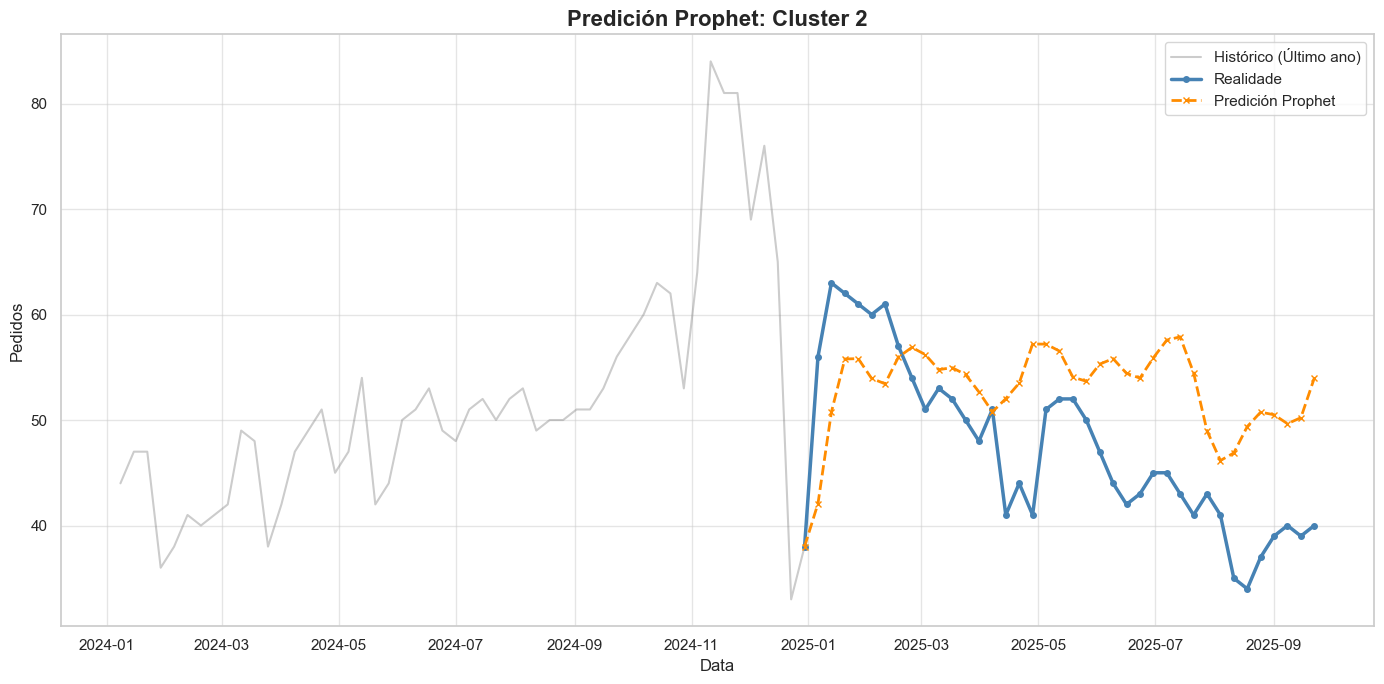

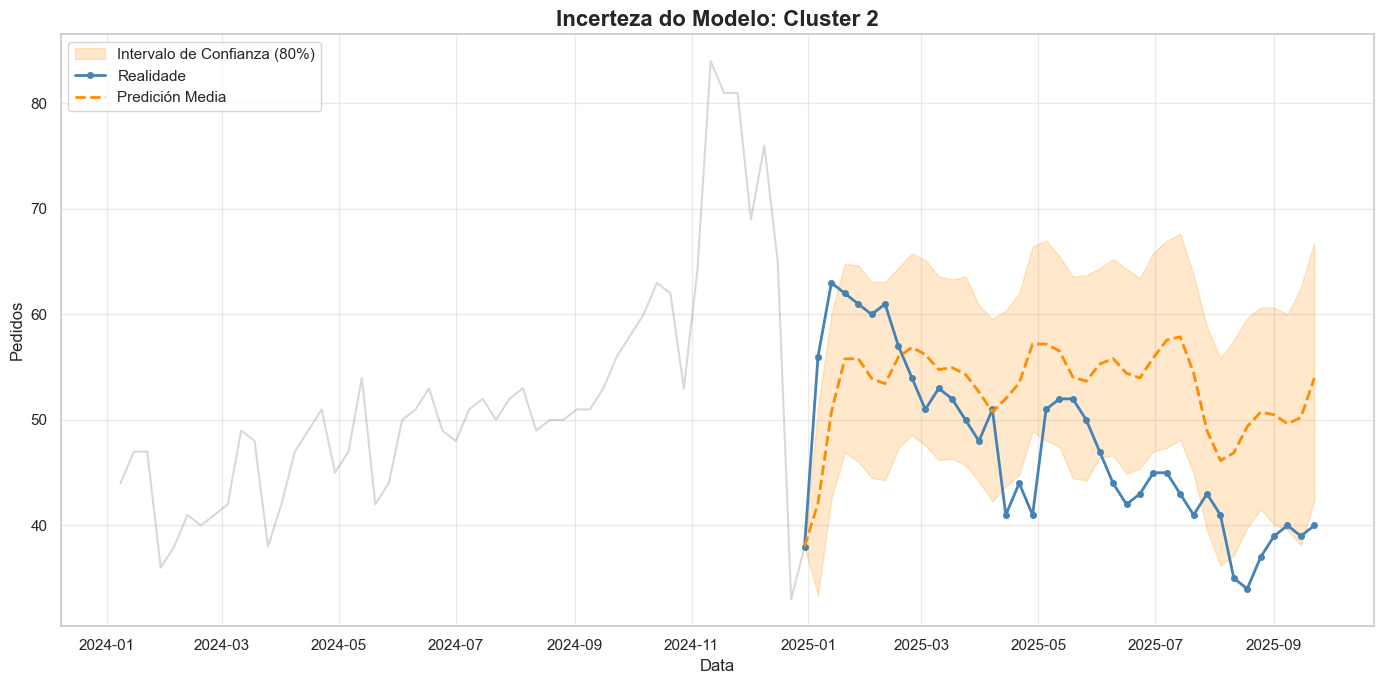

In [111]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [112]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Cluster 2 ---
MAE:  8.46
RMSE: 9.57
MAPE: 19.21%
MASE: 0.59 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


23:35:57 - cmdstanpy - INFO - Chain [1] start processing
23:35:57 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


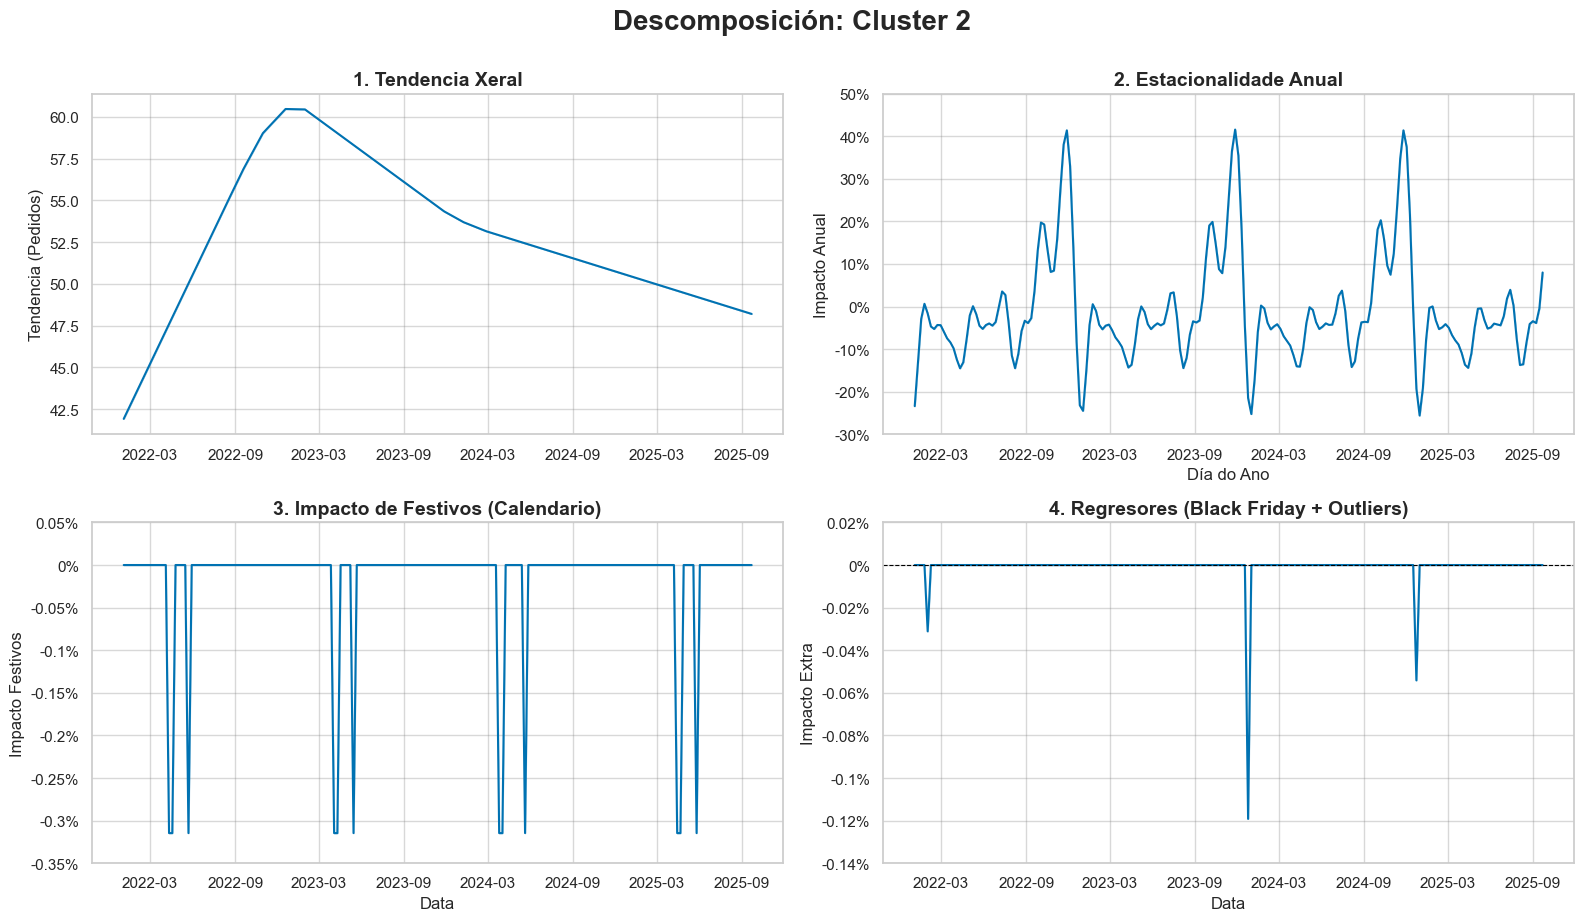

In [113]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Vemos como o MAPE = 17.91% e o MASE = 0.56. Novamente un bo modelo.

Representamos as compoñentes do modelo (o último axutado no Rolling-Window)

### Cluster 3

Por último, axustamos os modelos Prophet ao noso último cluster, que contén aos clientes de alimentación e industria:

Neste cluster aplicabamos transformación $log$ pola interpretación gráfica. Porén, como para este cluster nin o efecto do Black Friday nin os correspondentes outliers atopados eran significativos, empregar estacionalidade muktiplicativa pode causar malos resultados no Prophet.

Ademáis, por estos mesmos motivos (ausencia de regresores externos), á hora de establexer a malla de parámetros non deixamos que o modelo sexa moi conservador á hora de establecer os puntos de cambio, pois poderiamos caer nun problema de sobreaxuste aos datos de entrenamento.

In [183]:
modelo = 'Cluster 3'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 3
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (1): ['outlier_20220502']...
   Variables exóxenas detectadas (1): ['outlier_20220502']


In [184]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.5, 0.8, 0.9], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")

12:45:17 - cmdstanpy - INFO - Chain [1] start processing
12:45:17 - cmdstanpy - INFO - Chain [1] done processing



--- 🔧 TUNING: Cluster 3 ---
🚀 Iniciando Grid Search con 48 combinacións...


12:45:19 - cmdstanpy - INFO - Chain [1] start processing
12:45:19 - cmdstanpy - INFO - Chain [1] start processing
12:45:19 - cmdstanpy - INFO - Chain [1] start processing
12:45:19 - cmdstanpy - INFO - Chain [1] start processing
12:45:19 - cmdstanpy - INFO - Chain [1] done processing
12:45:19 - cmdstanpy - INFO - Chain [1] done processing
12:45:19 - cmdstanpy - INFO - Chain [1] start processing
12:45:19 - cmdstanpy - INFO - Chain [1] start processing
12:45:19 - cmdstanpy - INFO - Chain [1] done processing
12:45:19 - cmdstanpy - INFO - Chain [1] done processing
12:45:19 - cmdstanpy - INFO - Chain [1] done processing
12:45:19 - cmdstanpy - INFO - Chain [1] done processing
12:45:19 - cmdstanpy - INFO - Chain [1] start processing
12:45:19 - cmdstanpy - INFO - Chain [1] done processing
12:45:21 - cmdstanpy - INFO - Chain [1] start processing
12:45:21 - cmdstanpy - INFO - Chain [1] start processing
12:45:21 - cmdstanpy - INFO - Chain [1] done processing
12:45:21 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/48: RMSE=7.0722


12:45:29 - cmdstanpy - INFO - Chain [1] start processing
12:45:29 - cmdstanpy - INFO - Chain [1] start processing
12:45:29 - cmdstanpy - INFO - Chain [1] start processing
12:45:29 - cmdstanpy - INFO - Chain [1] start processing
12:45:29 - cmdstanpy - INFO - Chain [1] start processing
12:45:29 - cmdstanpy - INFO - Chain [1] start processing
12:45:29 - cmdstanpy - INFO - Chain [1] done processing
12:45:29 - cmdstanpy - INFO - Chain [1] done processing
12:45:29 - cmdstanpy - INFO - Chain [1] done processing
12:45:29 - cmdstanpy - INFO - Chain [1] done processing
12:45:29 - cmdstanpy - INFO - Chain [1] done processing
12:45:30 - cmdstanpy - INFO - Chain [1] done processing
12:45:30 - cmdstanpy - INFO - Chain [1] start processing
12:45:30 - cmdstanpy - INFO - Chain [1] done processing
12:45:32 - cmdstanpy - INFO - Chain [1] start processing
12:45:32 - cmdstanpy - INFO - Chain [1] start processing
12:45:32 - cmdstanpy - INFO - Chain [1] start processing
12:45:32 - cmdstanpy - INFO - Chain [1

...

12:46:58 - cmdstanpy - INFO - Chain [1] start processing
12:46:58 - cmdstanpy - INFO - Chain [1] start processing
12:46:58 - cmdstanpy - INFO - Chain [1] start processing
12:46:58 - cmdstanpy - INFO - Chain [1] start processing
12:46:58 - cmdstanpy - INFO - Chain [1] start processing
12:46:58 - cmdstanpy - INFO - Chain [1] start processing
12:46:58 - cmdstanpy - INFO - Chain [1] done processing
12:46:58 - cmdstanpy - INFO - Chain [1] done processing
12:46:58 - cmdstanpy - INFO - Chain [1] done processing
12:46:58 - cmdstanpy - INFO - Chain [1] done processing
12:46:58 - cmdstanpy - INFO - Chain [1] done processing
12:46:59 - cmdstanpy - INFO - Chain [1] done processing
12:46:59 - cmdstanpy - INFO - Chain [1] start processing
12:46:59 - cmdstanpy - INFO - Chain [1] done processing
12:47:01 - cmdstanpy - INFO - Chain [1] start processing
12:47:01 - cmdstanpy - INFO - Chain [1] start processing
12:47:01 - cmdstanpy - INFO - Chain [1] start processing
12:47:01 - cmdstanpy - INFO - Chain [1

   > Combinación 45/48: RMSE=8.2499


12:47:12 - cmdstanpy - INFO - Chain [1] done processing
12:47:13 - cmdstanpy - INFO - Chain [1] start processing
12:47:13 - cmdstanpy - INFO - Chain [1] done processing
12:47:13 - cmdstanpy - INFO - Chain [1] start processing
12:47:13 - cmdstanpy - INFO - Chain [1] start processing
12:47:13 - cmdstanpy - INFO - Chain [1] start processing
12:47:13 - cmdstanpy - INFO - Chain [1] start processing
12:47:13 - cmdstanpy - INFO - Chain [1] start processing
12:47:13 - cmdstanpy - INFO - Chain [1] done processing
12:47:13 - cmdstanpy - INFO - Chain [1] done processing
12:47:13 - cmdstanpy - INFO - Chain [1] done processing
12:47:13 - cmdstanpy - INFO - Chain [1] done processing
12:47:15 - cmdstanpy - INFO - Chain [1] done processing
12:47:15 - cmdstanpy - INFO - Chain [1] start processing
12:47:15 - cmdstanpy - INFO - Chain [1] done processing
12:47:16 - cmdstanpy - INFO - Chain [1] start processing
12:47:16 - cmdstanpy - INFO - Chain [1] start processing
12:47:16 - cmdstanpy - INFO - Chain [1]


✅ Grid Search Completado.
   Mellor RMSE: 6.7486
   Parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}


12:47:21 - cmdstanpy - INFO - Chain [1] done processing


In [185]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], # Usamos os que gañaron no tuning
    verbose=True
)

12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing



--- 🔮 ROLLING WINDOW: Cluster 3 ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:37 - cmdstanpy - INFO - Chain [1] done processing
12:48:37 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=25.13


12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=16.43


12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:38 - cmdstanpy - INFO - Chain [1] start processing
12:48:38 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=19.58


12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing
12:48:39 - cmdstanpy - INFO - Chain [1] start processing
12:48:39 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Cluster 3 ---


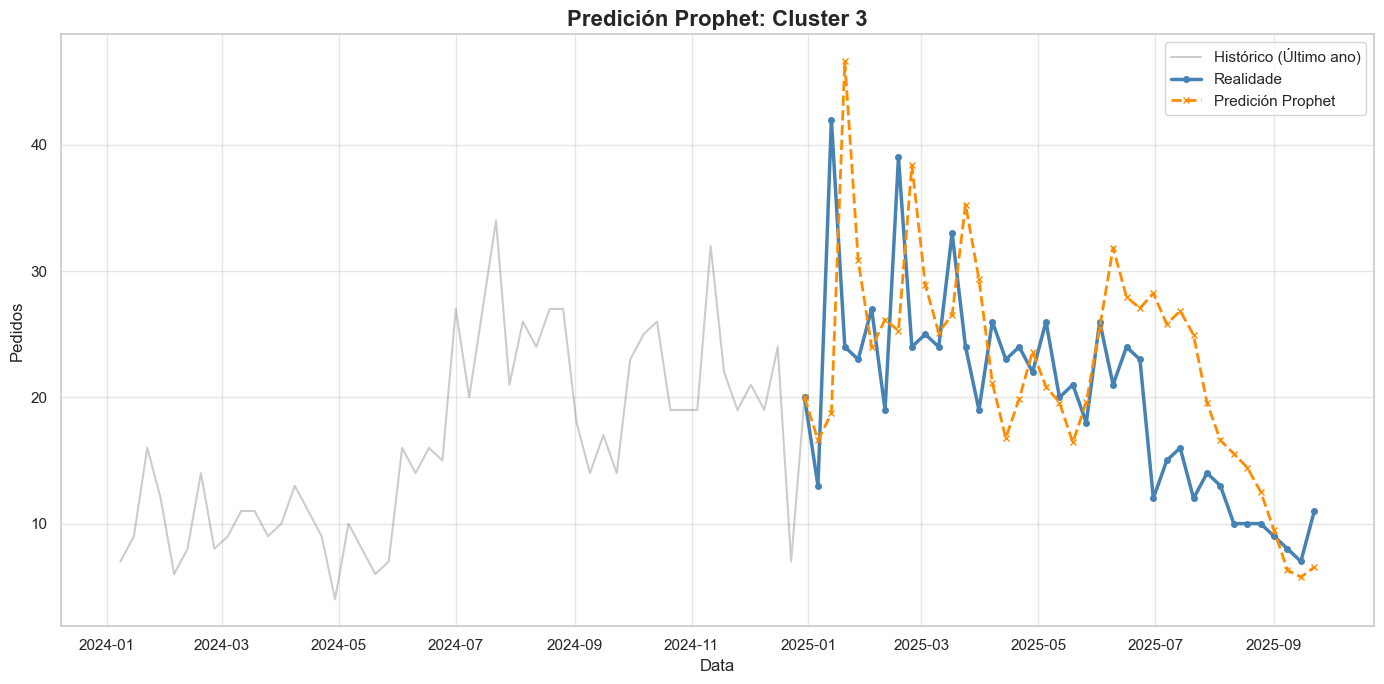

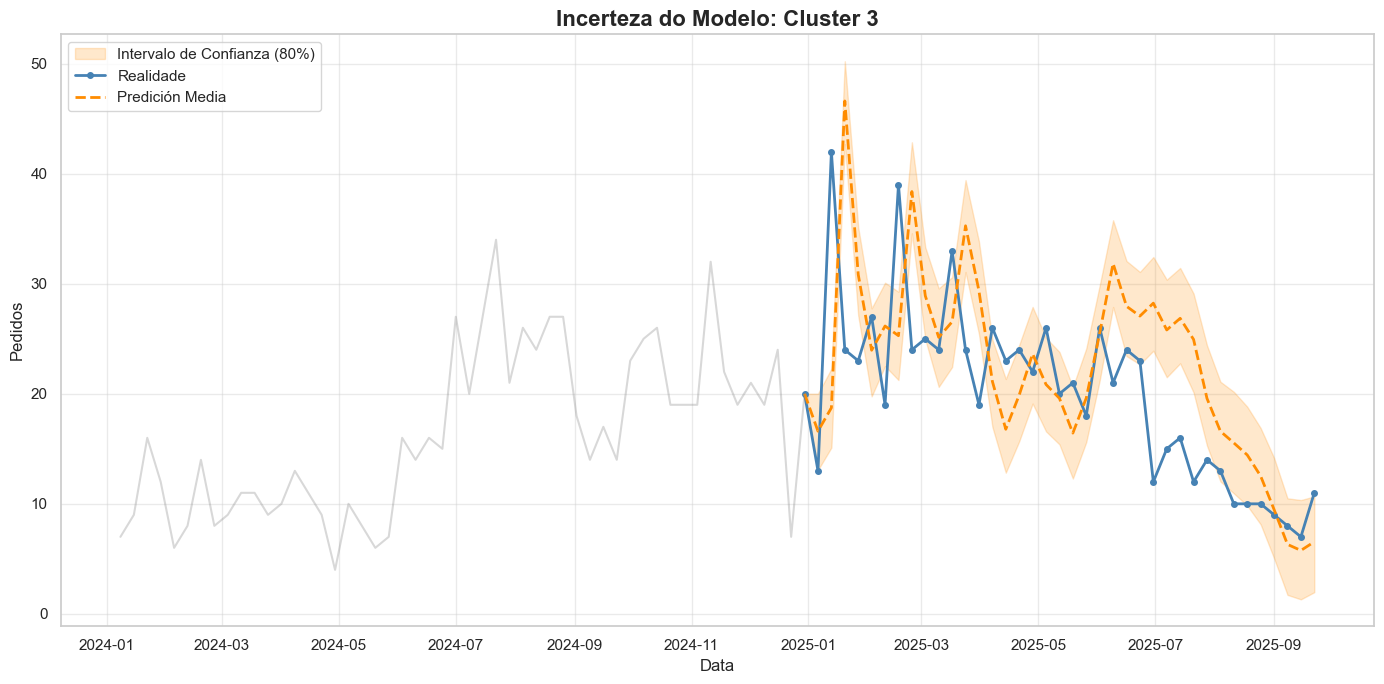

In [186]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [187]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Cluster 3 ---
MAE:  6.76
RMSE: 8.81
MAPE: 35.99%
MASE: 0.91 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos como o MAPE é relativamente elevado (35.84 %), por estar avaliando valores baixos (erros de apenas 6 pedidos son tan significativos). Porén, vemos un mellor comportamento do modelo fronte ao preditor naïve estacional (MASE = 0.97).

12:48:53 - cmdstanpy - INFO - Chain [1] start processing
12:48:53 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


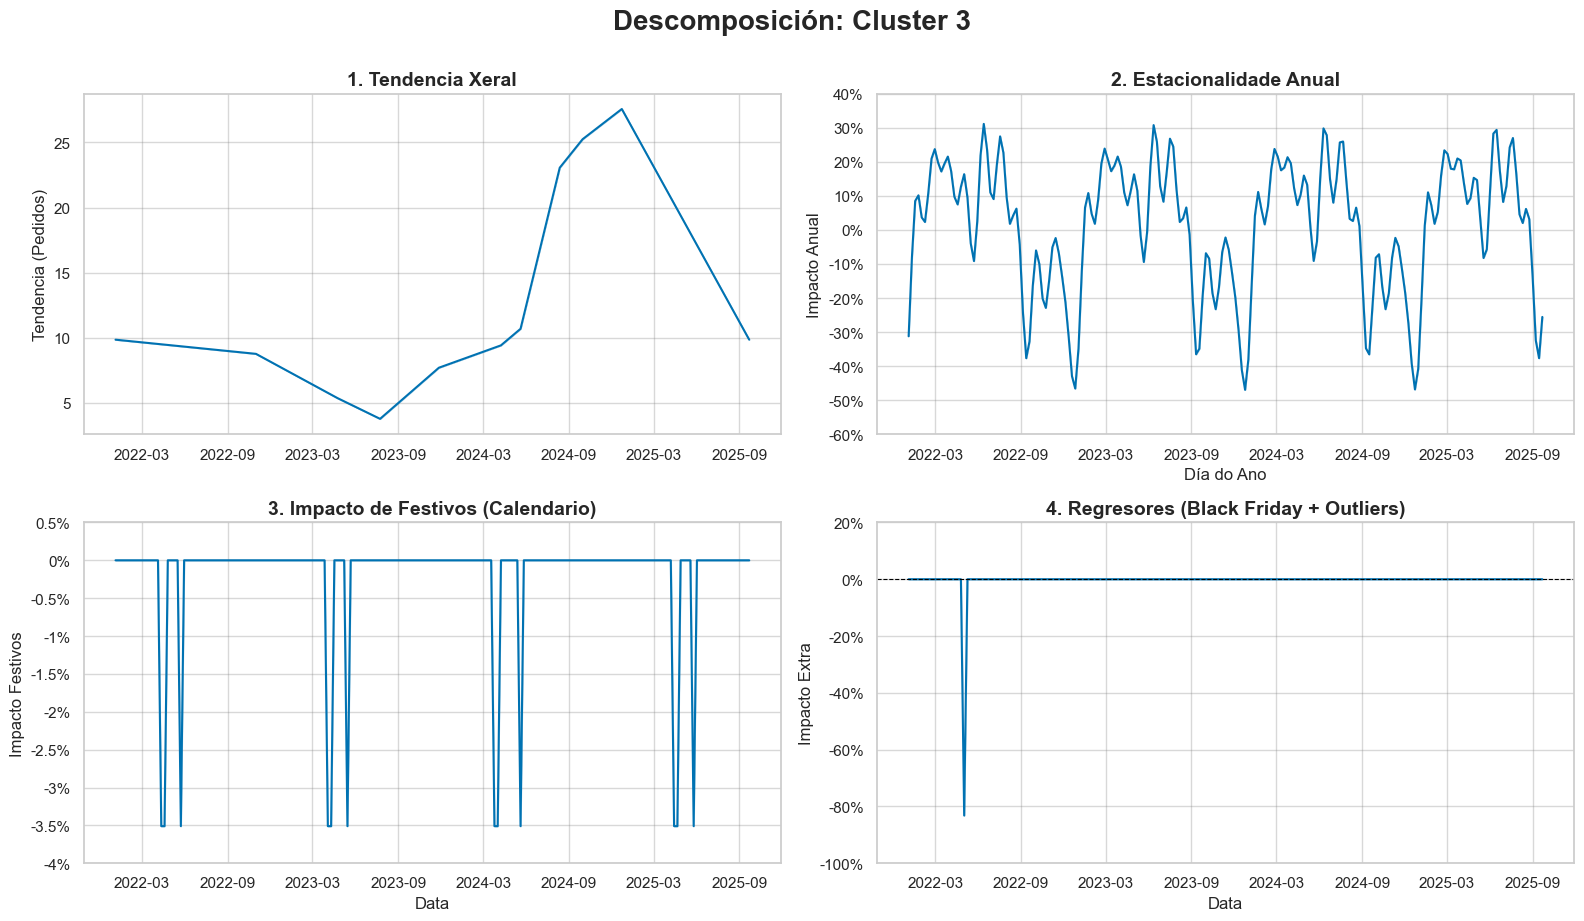

In [188]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Representamos as compoñentes do modelo:

In [189]:
print(resultados_prophet['Cluster 1']['metricas'])
print(resultados_prophet['Cluster 2']['metricas'])
print(resultados_prophet['Cluster 3']['metricas'])
print(resultados_prophet['Global']['metricas'])

{'MAE': 4.499011678362383, 'RMSE': np.float64(5.71860570745745), 'MAPE': np.float64(20.244483514100832), 'MASE': np.float64(0.3005065052341286)}
{'MAE': 8.455183435093494, 'RMSE': np.float64(9.572812318464981), 'MAPE': np.float64(19.213847487619663), 'MASE': np.float64(0.589896518727453)}
{'MAE': 6.764391150562288, 'RMSE': np.float64(8.808255884050988), 'MAPE': np.float64(35.98711892652319), 'MASE': np.float64(0.9117600395494739)}
{'MAE': 14.901801983991149, 'RMSE': np.float64(17.428146585163276), 'MAPE': np.float64(17.572604508073645), 'MASE': np.float64(0.7086454747821878)}


In [190]:
modelo = 'Cluster 3'
print(datos_arima[modelo]['metricas'])
print(resultados_prophet[modelo]['metricas'])

{'MAE': 2.816251972474634, 'RMSE': np.float64(3.5269302406152123), 'MAPE': np.float64(19.883703390079113), 'MASE': np.float64(0.9387506574915444)}
{'MAE': 6.764391150562288, 'RMSE': np.float64(8.808255884050988), 'MAPE': np.float64(35.98711892652319), 'MASE': np.float64(0.9117600395494739)}


#### Comparación de rendementos:

Da mesma forma que fixemos nos ARIMA, podemos comparar os resultados do modelo Prophet xeral coa ponderación dos modelos por Cluster:

--- ⚖️ COMPARATIVA FINAL: GLOBAL vs CLUSTERS PONDERADOS ---
Volume Total: 19406 pedidos.
Pesos calculados:
   > Cluster 1: 34.98%
   > Cluster 2: 52.68%
   > Cluster 3: 12.34%

Métrica    | Modelo Único    | Clusters Pond.  | Mellora
------------------------------------------------------------
MAE        | 14.90           | 6.86            | +8.04  ✅
RMSE       | 17.43           | 8.13            | +9.30  ✅
MAPE       | 17.57         % | 21.64         % | -4.07% ❌
MASE       | 0.71            | 0.53            | +0.18  ✅


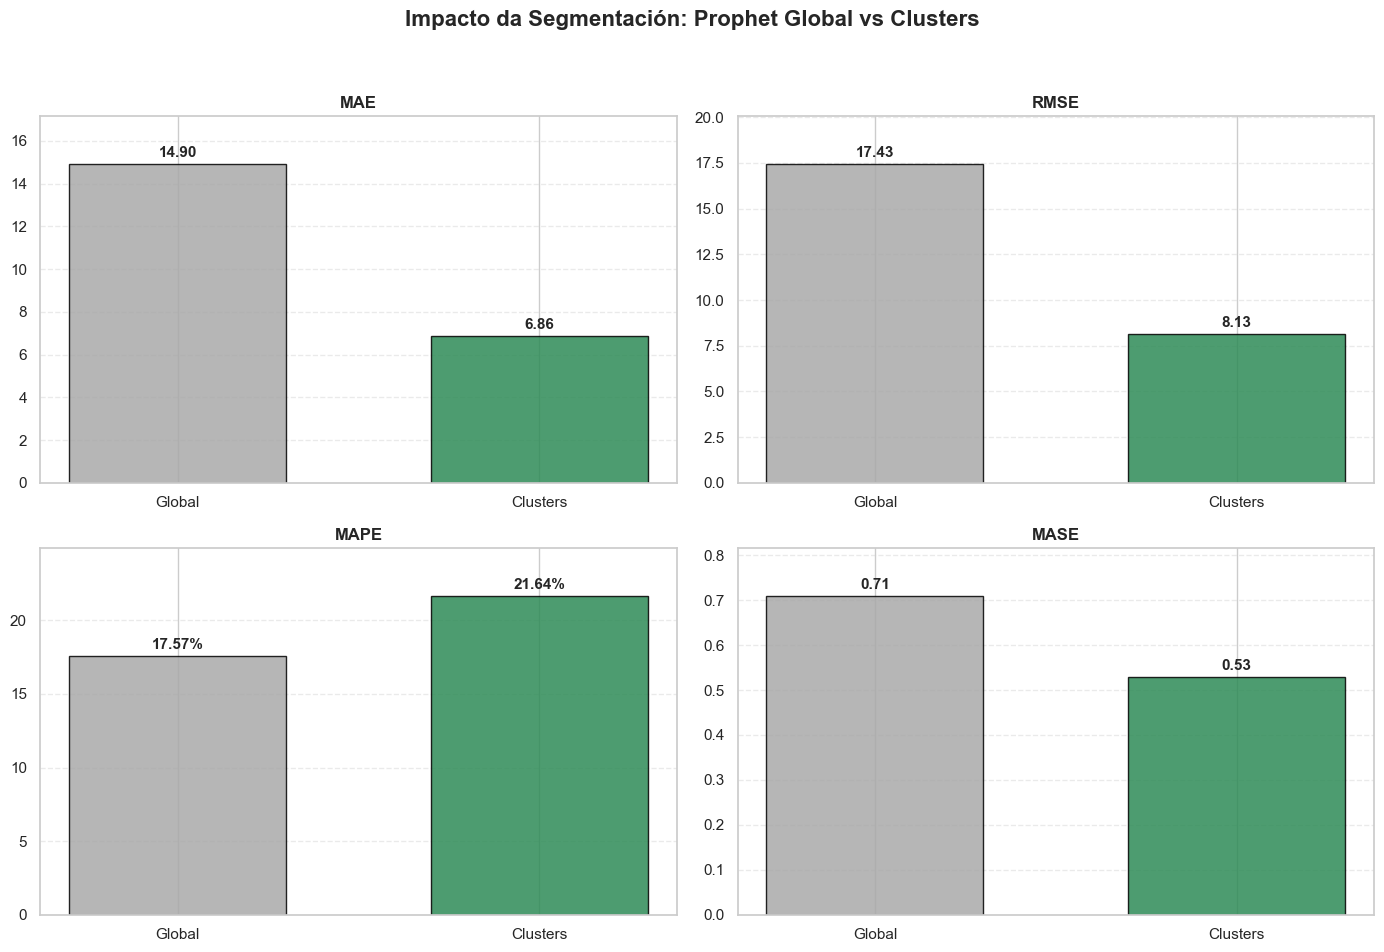

In [191]:
print("--- ⚖️ COMPARATIVA FINAL: GLOBAL vs CLUSTERS PONDERADOS ---")

# 1. CÁLCULO DOS PESOS (Baseado no volume real de pedidos)
# Usamos o dicionario 'datos' orixinal para saber canto pesa cada cluster
volumen_total = datos['Global']['n_pedidos'].sum()

clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
lista_metricas = []

print(f"Volume Total: {volumen_total} pedidos.")
print("Pesos calculados:")

for c in clusters:
    # A. Calculamos o peso do cluster
    vol_cluster = datos[c]['n_pedidos'].sum()
    peso = vol_cluster / volumen_total
    print(f"   > {c}: {peso:.2%}")
    
    # B. Recuperamos as métricas gardadas
    # NOTA: Se para o Cluster 3 gardaches as métricas "Sen Q1" no paso anterior,
    # este código usaráas automaticamente.
    m = resultados_prophet[c]['metricas']
    
    lista_metricas.append({
        'Cluster': c,
        'MAE': m['MAE'],
        'RMSE': m['RMSE'],
        'MAPE': m['MAPE'],
        'MASE': m['MASE'],
        'Peso': peso
    })

# Convertemos a DataFrame para facilitar o cálculo
df_comp = pd.DataFrame(lista_metricas)

# 2. CÁLCULO PONDERADO (A media dos clusters axustada polo seu tamaño)
w_mae  = (df_comp['MAE'] * df_comp['Peso']).sum()
w_rmse = (df_comp['RMSE'] * df_comp['Peso']).sum()
w_mape = (df_comp['MAPE'] * df_comp['Peso']).sum()
w_mase = (df_comp['MASE'] * df_comp['Peso']).sum()

# 3. RECUPERAMOS MÉTRICAS DO GLOBAL
met_global = resultados_prophet['Global']['metricas']

# 4. TÁBOA DE RESULTADOS NUMÉRICOS
print("\n" + "="*60)
print(f"{'Métrica':<10} | {'Modelo Único':<15} | {'Clusters Pond.':<15} | {'Mellora'}")
print("-" * 60)

# Función auxiliar para imprimir filas
def print_row(name, val_g, val_w, is_percent=False):
    diff = val_g - val_w
    # Se a diferenza é positiva, o erro baixou (Mellora ✅)
    icon = "✅" if diff > 0 else "❌"
    
    if is_percent:
        print(f"{name:<10} | {val_g:<14.2f}% | {val_w:<14.2f}% | {diff:+.2f}% {icon}")
    else:
        print(f"{name:<10} | {val_g:<14.2f}  | {val_w:<14.2f}  | {diff:+.2f}  {icon}")

print_row("MAE", met_global['MAE'], w_mae)
print_row("RMSE", met_global['RMSE'], w_rmse)
print_row("MAPE", met_global['MAPE'], w_mape, is_percent=True)
print_row("MASE", met_global['MASE'], w_mase)
print("="*60)

# 5. VISUALIZACIÓN GRÁFICA
metrics_names = ['MAE', 'RMSE', 'MAPE', 'MASE']
vals_global = [met_global['MAE'], met_global['RMSE'], met_global['MAPE'], met_global['MASE']]
vals_weighted = [w_mae, w_rmse, w_mape, w_mase]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Impacto da Segmentación: Prophet Global vs Clusters', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()
colors = ['#A9A9A9', '#2E8B57'] # Gris (Global) vs Verde (Clusters)

for i, metric in enumerate(metrics_names):
    ax = axes_flat[i]
    
    # Pintamos as barras
    bars = ax.bar(['Global', 'Clusters'], [vals_global[i], vals_weighted[i]], 
                  color=colors, alpha=0.85, edgecolor='black', width=0.6)
    
    # Títulos e Estética
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Engadimos o valor enriba da barra
    fmt = '%.2f%%' if metric == 'MAPE' else '%.2f'
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=11, fontweight='bold')
    
    # Marges para que non toque o teito
    ax.set_ylim(0, max(vals_global[i], vals_weighted[i]) * 1.15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()